# Load & Test — xgb_v4_OTA2201_20260602_1457

Loads the saved XGBoost model and runs a rolling 1-week prediction
on the first week of August 2024.

Preprocessing is identical to `xgboost_v4_search.ipynb` (v3 pipeline on old data).


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [83]:
# ── Load saved model ──────────────────────────────────────────────────────────

MODEL_PATH = "./xgb_v4_OTA2201_20260602_1457.ubj"

model = XGBRegressor()
model.load_model(MODEL_PATH)

print(f"Model loaded: {MODEL_PATH}")

Model loaded: ./xgb_v4_OTA2201_20260602_1457.ubj


In [84]:
# ── Load data — identical to v4_search ───────────────────────────────────────

df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print("Shape:", df.shape)

Shape: (52585, 81)


In [85]:
# ── Preprocessing — identical to v4_search ────────────────────────────────────

df = df.ffill()

cols_to_shift_24h = [
    c for c in df.columns if "el_price" in c and c != target_col
] + [
    "Coal","Diesel","Ele","Gas","Geo","Hydro","Solar","Wind","Wood",
    "demand_GWh_CNI","demand_GWh_LNI","demand_GWh_LSI","demand_GWh_UNI","demand_GWh_USI",
    "avg_flow_MW","peak_flow_MW","Direction"
]
for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

df["hour"]       = df["datetime_utc12"].dt.hour
df["dayofweek"]  = df["datetime_utc12"].dt.dayofweek
df["month"]      = df["datetime_utc12"].dt.month
df["dayofyear"]  = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
df["hour_sin"]   = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]   = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]    = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]    = np.cos(2*np.pi*df["dayofweek"]/7)
df["month_sin"]  = np.sin(2*np.pi*df["month"]/12)
df["month_cos"]  = np.cos(2*np.pi*df["month"]/12)

df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window).std()

df = df.dropna().reset_index(drop=True)
print(f"Rows after cleanup: {len(df)}")
print(f"Date range: {df['datetime_utc12'].iloc[0].date()} → {df['datetime_utc12'].iloc[-1].date()}")

Rows after cleanup: 43825
Date range: 2020-01-01 → 2024-12-31


In [86]:
# ── Define feature columns ────────────────────────────────────────────────────

exclude_cols = ["datetime_utc12", target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f"Features: {len(feature_cols)}")

Features: 99


In [87]:
# ── Predict every day of 2024 ─────────────────────────────────────────────────

results = []

dates_2024 = pd.date_range("2024-01-01", "2024-12-31", freq="D")

for date in dates_2024:
    mask = (
        (df["datetime_utc12"] >= date) &
        (df["datetime_utc12"] <  date + pd.Timedelta(hours=24))
    )
    day_df = df[mask]

    if len(day_df) < 24:
        continue

    X_day    = day_df[feature_cols].values
    y_actual = day_df[target_col].values
    y_naive  = day_df["target_lag_24h"].values
    y_pred   = model.predict(X_day)

    mae_model = mean_absolute_error(y_actual, y_pred)
    mae_naive = mean_absolute_error(y_actual, y_naive)
    std_price = np.std(y_actual)
    max_price = np.max(y_actual)

    results.append({
        "date":              date.date(),
        "mae_model":         mae_model,
        "mae_naive":         mae_naive,
        "std_actual":        std_price,
        "max_actual":        max_price,
        "beats_naive":       mae_model < mae_naive,
        "score_std_per_mae": std_price / mae_model if mae_model > 0 else np.nan,
    })

results_df = pd.DataFrame(results)
results_df["naive_advantage"] = results_df["mae_naive"] - results_df["mae_model"]

print(f"Days predicted      : {len(results_df)}")
print(f"Days beats naive    : {results_df['beats_naive'].sum()} / {len(results_df)}")
print(f"Days with max > 1000: {(results_df['max_actual'] > 1000).sum()}")

Days predicted      : 365
Days beats naive    : 258 / 365
Days with max > 1000: 10


          date  mae_model  mae_naive  std_actual  beats_naive
1   2024-11-02       5.54       7.78        5.84         True
2   2024-12-26       6.35       5.96        3.69        False
3   2024-12-29       7.81       2.32        3.92        False
4   2024-12-27       8.20       4.03        3.58        False
5   2024-11-09       8.73      17.51        3.20         True
6   2024-09-08       9.40       5.58        5.62        False
7   2024-12-24       9.92       3.99        8.23        False
8   2024-09-07      10.02      12.18       14.50         True
9   2024-11-01      10.13      11.35       10.44         True
10  2024-04-02      11.05      32.49       26.30         True


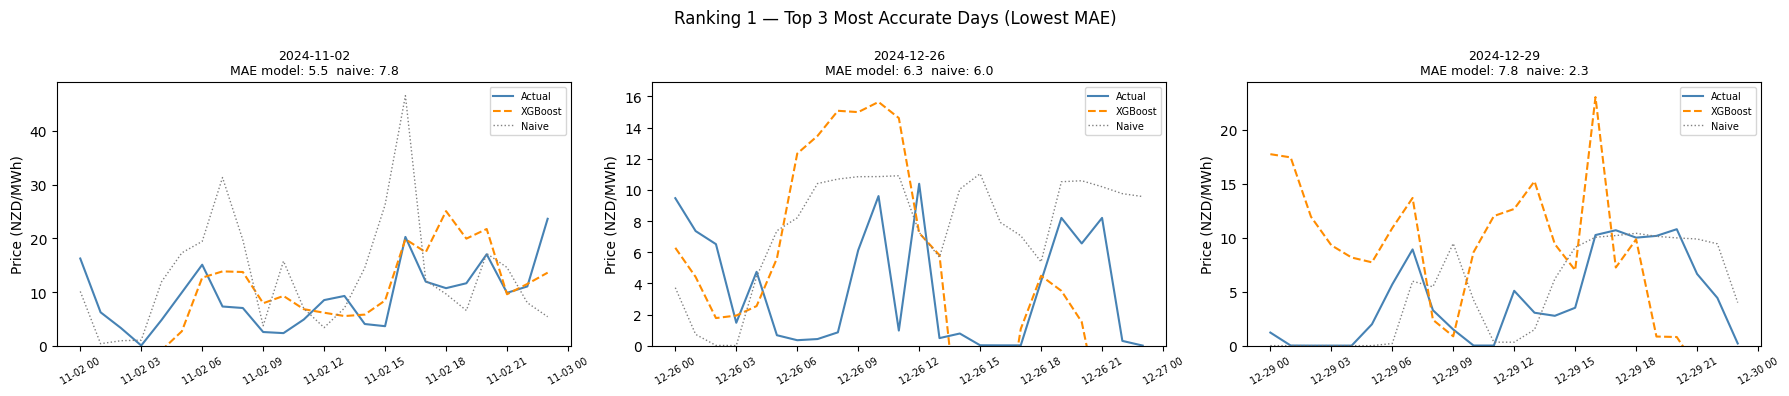

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
# RANKING 1 — TOP 10 DAYS: Lowest Model MAE
# Most accurate days overall regardless of volatility
# ══════════════════════════════════════════════════════════════════════════════

pd.set_option("display.float_format", "{:.2f}".format)

top_mae = results_df.nsmallest(10, "mae_model")[
    ["date", "mae_model", "mae_naive", "std_actual", "beats_naive"]
].reset_index(drop=True)
top_mae.index += 1
print(top_mae.to_string())

# ── Plot top 3 ────────────────────────────────────────────────────────────────

def plot_day(ax, date, title):
    mask = (
        (df["datetime_utc12"] >= pd.Timestamp(date)) &
        (df["datetime_utc12"] <  pd.Timestamp(date) + pd.Timedelta(hours=24))
    )
    d        = df[mask]
    ts       = d["datetime_utc12"].values
    y_actual = d[target_col].values
    y_pred   = model.predict(d[feature_cols].values)
    y_naive  = d["target_lag_24h"].values
    mae_m    = mean_absolute_error(y_actual, y_pred)
    mae_n    = mean_absolute_error(y_actual, y_naive)

    ax.plot(ts, y_actual, label="Actual",  color="steelblue",  linewidth=1.5)
    ax.plot(ts, y_pred,   label="XGBoost", color="darkorange", linewidth=1.5, linestyle="--")
    ax.plot(ts, y_naive,  label="Naive",   color="gray",       linewidth=1.0, linestyle=":")
    ax.set_title(f"{title}\nMAE model: {mae_m:.1f}  naive: {mae_n:.1f}", fontsize=9)
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Ranking 1 — Top 3 Most Accurate Days (Lowest MAE)", fontsize=12)
for i, ax in enumerate(axes):
    date = top_mae.iloc[i]["date"]
    plot_day(ax, date, str(date))
plt.tight_layout()
plt.show()

          date  mae_model  mae_naive  naive_advantage  std_actual
1   2024-12-13      33.68     258.81           225.13       11.36
2   2024-05-09     292.76     450.18           157.42      674.26
3   2024-08-12      96.39     243.96           147.58      160.73
4   2024-09-18      82.46     198.11           115.66       59.32
5   2024-08-15      90.18     189.53            99.35      101.90
6   2024-02-23     101.38     199.62            98.24       50.11
7   2024-05-10     196.28     292.05            95.78      305.39
8   2024-07-06      49.64     131.36            81.72       67.09
9   2024-07-31      49.98     128.66            78.69       28.74
10  2024-01-30     117.64     192.65            75.01      206.48


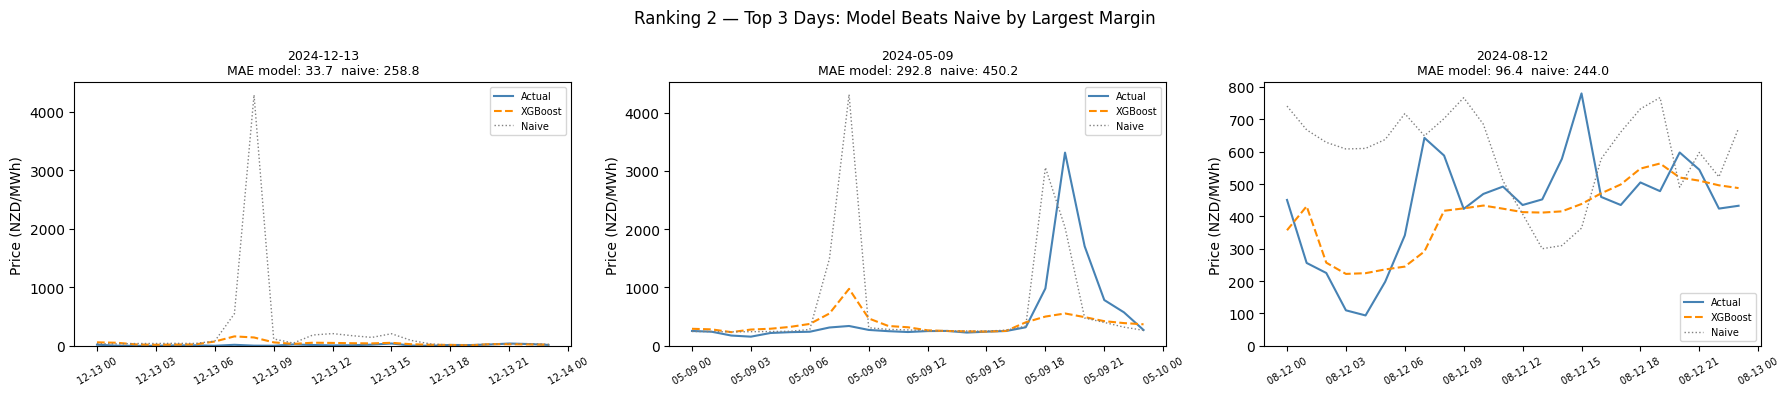

In [89]:
# ══════════════════════════════════════════════════════════════════════════════
# RANKING 2 — TOP 10 DAYS: Model Beats Naive by Largest Margin
# Days where the model added the most value over simply using yesterday
# (only days where model actually wins)
# ══════════════════════════════════════════════════════════════════════════════

beats = results_df[results_df["beats_naive"]].nlargest(10, "naive_advantage")[
    ["date", "mae_model", "mae_naive", "naive_advantage", "std_actual"]
].reset_index(drop=True)
beats.index += 1
print(beats.to_string())

# ── Plot top 3 ────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Ranking 2 — Top 3 Days: Model Beats Naive by Largest Margin", fontsize=12)
for i, ax in enumerate(axes):
    date = beats.iloc[i]["date"]
    plot_day(ax, date, str(date))
plt.tight_layout()
plt.show()

Days excluded (max price > 1000): 10  |  Remaining: 355

── TOP 10: Volatile days where model was most accurate ──
          date  score_std_per_mae  std_actual  max_actual  mae_model  mae_naive  beats_naive
1   2024-07-04               3.76       88.11      527.43      23.40      83.17         True
2   2024-07-26               3.22       94.41      785.94      29.31      34.67         True
3   2024-01-18               3.07       64.42      458.75      20.96      38.88         True
4   2024-01-21               2.67       60.37      339.35      22.59      46.36         True
5   2024-07-25               2.58       44.67      493.54      17.31      42.15         True
6   2024-01-12               2.50       52.02      318.02      20.83      58.37         True
7   2024-03-18               2.49       69.08      281.93      27.76      41.46         True
8   2024-04-02               2.38       26.30      318.76      11.05      32.49         True
9   2024-01-09               2.36       47.58   

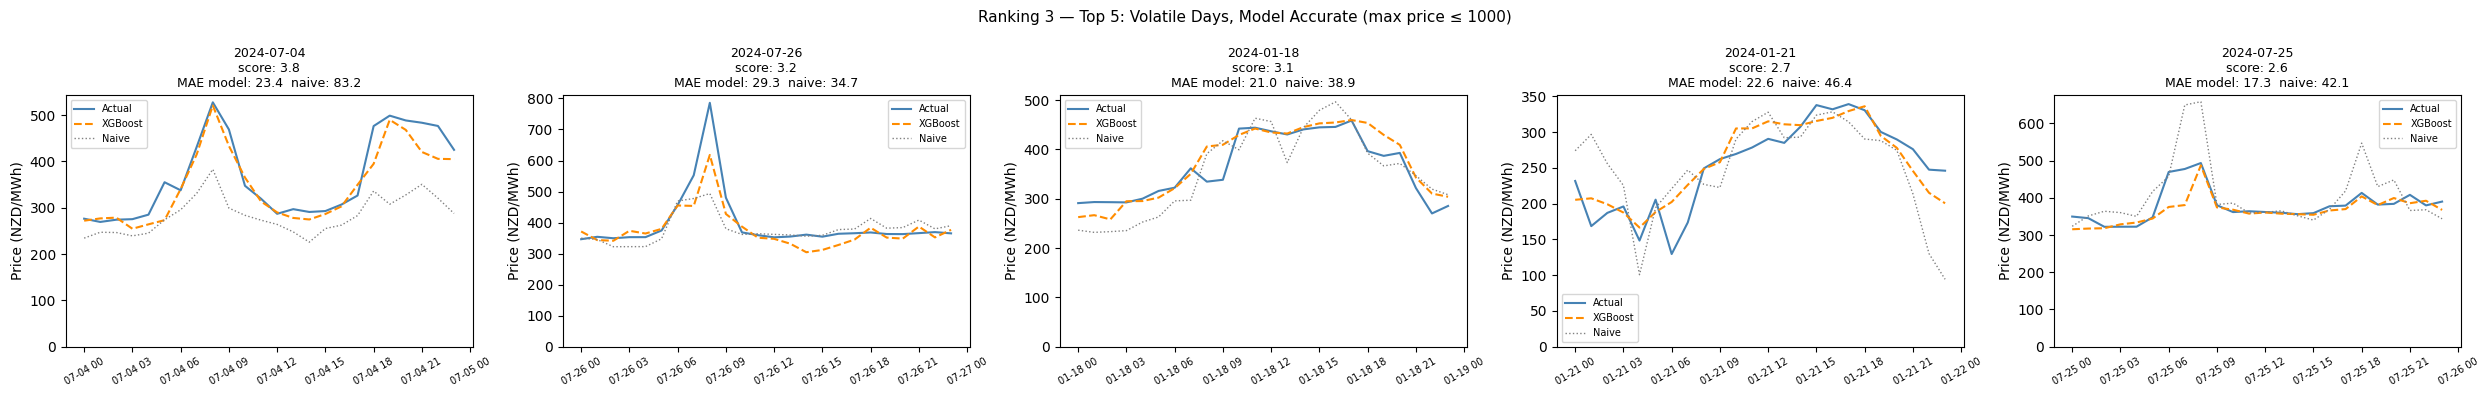

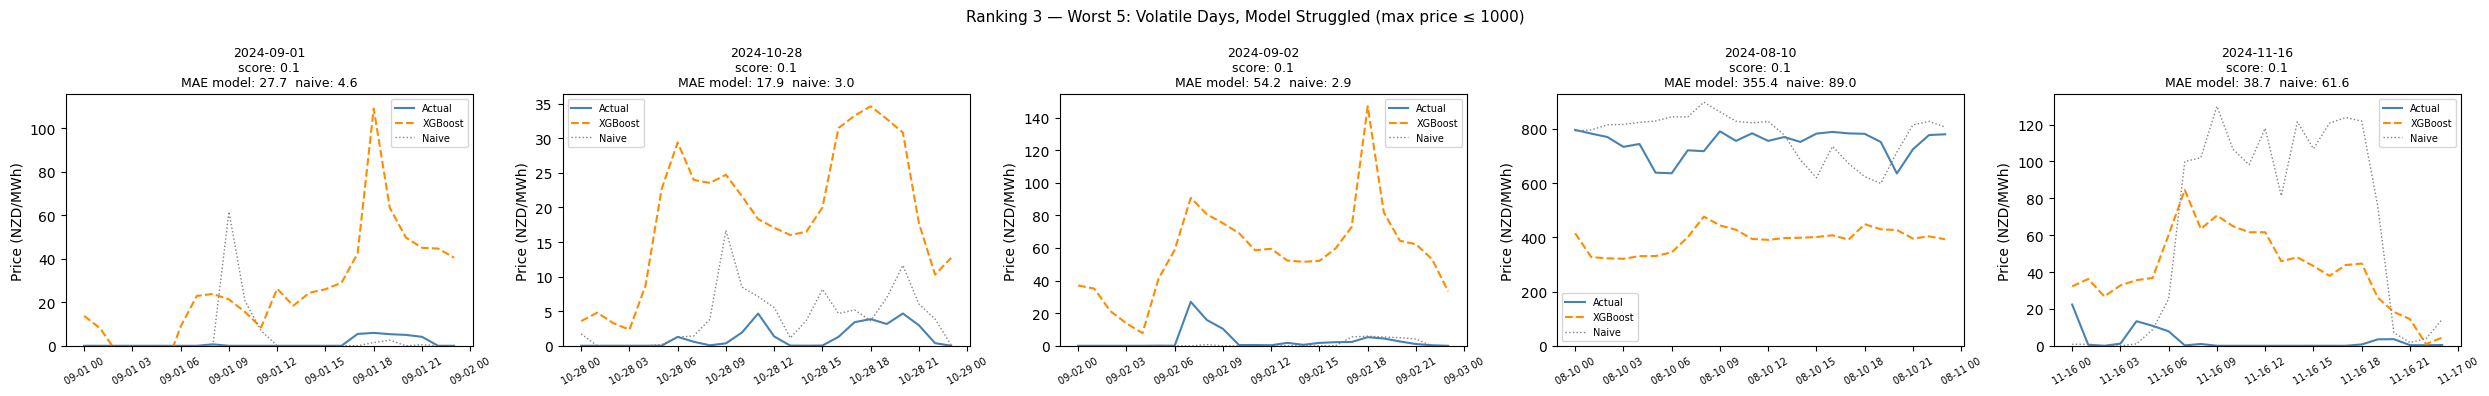


FULL YEAR 2024 — Summary
  Days predicted    : 365
  Avg model MAE     : 49.81 NZD/MWh
  Avg naive MAE     : 56.23 NZD/MWh
  Avg MASE          : 1.106
  Days beats naive  : 258 / 365


In [90]:
# ══════════════════════════════════════════════════════════════════════════════
# RANKING 3 — VOLATILE BUT ACCURATE: score = std / model_MAE
# Excludes days where any hour exceeded 1000 NZD/MWh — those days have
# artificially large std from a single extreme spike, not genuine volatility.
# ══════════════════════════════════════════════════════════════════════════════

SPIKE_EXCLUDE = 1000   # NZD/MWh — tweak if needed

r3 = results_df[results_df["max_actual"] <= SPIKE_EXCLUDE].copy()
excluded = len(results_df) - len(r3)
print(f"Days excluded (max price > {SPIKE_EXCLUDE}): {excluded}  |  Remaining: {len(r3)}\n")

top_score  = r3.nlargest(10,  "score_std_per_mae")
worst_score = r3.nsmallest(10, "score_std_per_mae")

cols_show = ["date", "score_std_per_mae", "std_actual", "max_actual", "mae_model", "mae_naive", "beats_naive"]

print("── TOP 10: Volatile days where model was most accurate ──")
ts_print = top_score[cols_show].reset_index(drop=True)
ts_print.index += 1
print(ts_print.to_string())

print("\n── WORST 10: Volatile days where model struggled most ──")
ws_print = worst_score[cols_show].reset_index(drop=True)
ws_print.index += 1
print(ws_print.to_string())

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
fig.suptitle(f"Ranking 3 — Top 5: Volatile Days, Model Accurate (max price ≤ {SPIKE_EXCLUDE})", fontsize=11)
for i, ax in enumerate(axes):
    date  = top_score.iloc[i]["date"]
    score = top_score.iloc[i]["score_std_per_mae"]
    plot_day(ax, date, f"{date}\nscore: {score:.1f}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(25, 4))
fig.suptitle(f"Ranking 3 — Worst 5: Volatile Days, Model Struggled (max price ≤ {SPIKE_EXCLUDE})", fontsize=11)
for i, ax in enumerate(axes):
    date  = worst_score.iloc[i]["date"]
    score = worst_score.iloc[i]["score_std_per_mae"]
    plot_day(ax, date, f"{date}\nscore: {score:.1f}")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FULL YEAR 2024 — Summary")
print("=" * 60)
print(f"  Days predicted    : {len(results_df)}")
print(f"  Avg model MAE     : {results_df['mae_model'].mean():.2f} NZD/MWh")
print(f"  Avg naive MAE     : {results_df['mae_naive'].mean():.2f} NZD/MWh")
print(f"  Avg MASE          : {(results_df['mae_model'] / results_df['mae_naive']).mean():.3f}")
print(f"  Days beats naive  : {results_df['beats_naive'].sum()} / {len(results_df)}")

In [91]:
# ══════════════════════════════════════════════════════════════════════════════
# WEEKLY ANALYSIS — Predict each week of 2024
# ══════════════════════════════════════════════════════════════════════════════

week_results = []

week_starts = pd.date_range("2024-01-01", "2024-12-25", freq="7D")

for week_start in week_starts:
    week_end = week_start + pd.Timedelta(days=7)
    mask = (
        (df["datetime_utc12"] >= week_start) &
        (df["datetime_utc12"] <  week_end)
    )
    week_df = df[mask]

    if len(week_df) < 168:
        continue

    X_week   = week_df[feature_cols].values
    y_actual = week_df[target_col].values
    y_naive  = week_df["target_lag_24h"].values
    y_pred   = model.predict(X_week)

    mae_model = mean_absolute_error(y_actual, y_pred)
    mae_naive = mean_absolute_error(y_actual, y_naive)
    std_price = np.std(y_actual)
    max_price = np.max(y_actual)

    week_results.append({
        "week_start":        week_start.date(),
        "week_end":          (week_end - pd.Timedelta(days=1)).date(),
        "mae_model":         mae_model,
        "mae_naive":         mae_naive,
        "std_actual":        std_price,
        "max_actual":        max_price,
        "beats_naive":       mae_model < mae_naive,
        "score_std_per_mae": std_price / mae_model if mae_model > 0 else np.nan,
    })

week_df_results = pd.DataFrame(week_results)
week_df_results["naive_advantage"] = week_df_results["mae_naive"] - week_df_results["mae_model"]

print(f"Weeks predicted      : {len(week_df_results)}")
print(f"Weeks beats naive    : {week_df_results['beats_naive'].sum()} / {len(week_df_results)}")
print(f"Weeks with max > 1000: {(week_df_results['max_actual'] > 1000).sum()}")

def plot_week(ax, week_start, title):
    week_end = pd.Timestamp(week_start) + pd.Timedelta(days=7)
    mask = (
        (df["datetime_utc12"] >= pd.Timestamp(week_start)) &
        (df["datetime_utc12"] <  week_end)
    )
    d        = df[mask]
    ts       = d["datetime_utc12"].values
    y_actual = d[target_col].values
    y_pred   = model.predict(d[feature_cols].values)
    y_naive  = d["target_lag_24h"].values
    mae_m    = mean_absolute_error(y_actual, y_pred)
    mae_n    = mean_absolute_error(y_actual, y_naive)

    ax.plot(ts, y_actual, label="Actual",  color="steelblue",  linewidth=1.0)
    ax.plot(ts, y_pred,   label="XGBoost", color="darkorange", linewidth=1.0, linestyle="--")
    ax.plot(ts, y_naive,  label="Naive",   color="gray",       linewidth=0.8, linestyle=":")
    ax.set_title(f"{title}\nMAE model: {mae_m:.1f}  naive: {mae_n:.1f}", fontsize=8)
    ax.set_ylabel("Price (NZD/MWh)")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", labelrotation=30, labelsize=6)
    ax.legend(fontsize=6)

Weeks predicted      : 52
Weeks beats naive    : 43 / 52
Weeks with max > 1000: 7


    week_start    week_end  mae_model  mae_naive  std_actual  beats_naive
1   2024-12-23  2024-12-29      10.38       4.75        6.48        False
2   2024-11-18  2024-11-24      14.68      13.41       14.59        False
3   2024-10-28  2024-11-03      14.68      13.61       19.42        False
4   2024-10-21  2024-10-27      19.43      20.50       38.47         True
5   2024-12-02  2024-12-08      20.28      30.86       41.30         True
6   2024-01-08  2024-01-14      22.40      32.42       38.04         True
7   2024-04-01  2024-04-07      23.15      29.40       34.46         True
8   2024-03-18  2024-03-24      23.73      30.46       47.48         True
9   2024-12-16  2024-12-22      24.17      31.43       46.45         True
10  2024-11-04  2024-11-10      25.11      41.78       50.39         True


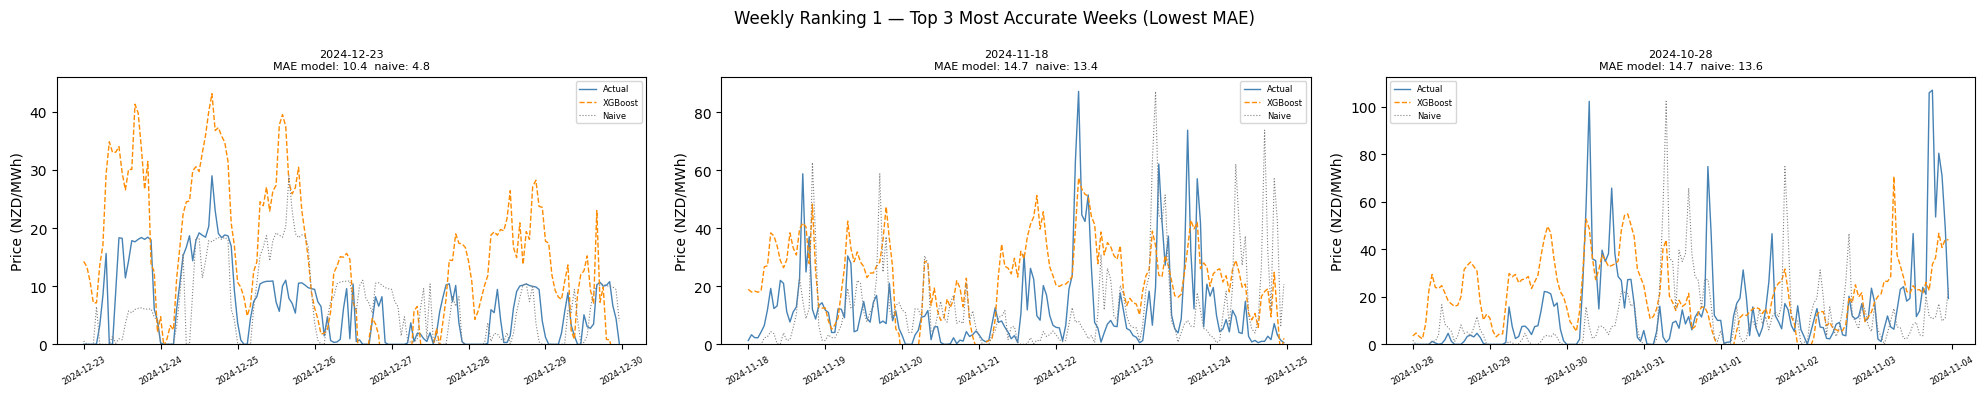

In [92]:
# ══════════════════════════════════════════════════════════════════════════════
# WEEKLY RANKING 1 — TOP 10 WEEKS: Lowest Model MAE
# ══════════════════════════════════════════════════════════════════════════════

top_mae_w = week_df_results.nsmallest(10, "mae_model")[
    ["week_start", "week_end", "mae_model", "mae_naive", "std_actual", "beats_naive"]
].reset_index(drop=True)
top_mae_w.index += 1
print(top_mae_w.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
fig.suptitle("Weekly Ranking 1 — Top 3 Most Accurate Weeks (Lowest MAE)", fontsize=12)
for i, ax in enumerate(axes):
    ws = top_mae_w.iloc[i]["week_start"]
    plot_week(ax, ws, str(ws))
plt.tight_layout()
plt.show()

    week_start    week_end  mae_model  mae_naive  naive_advantage  std_actual
1   2024-08-12  2024-08-18     109.12     157.24            48.12      159.61
2   2024-07-01  2024-07-07      45.40      81.99            36.59      130.27
3   2024-12-09  2024-12-15      50.67      87.25            36.57      331.41
4   2024-05-06  2024-05-12     164.31     194.62            30.31      499.00
5   2024-09-16  2024-09-22      66.21      96.44            30.23      193.25
6   2024-02-19  2024-02-25      72.25     100.25            28.00      132.45
7   2024-08-19  2024-08-25      57.06      84.98            27.92      127.55
8   2024-07-15  2024-07-21      51.79      78.88            27.08       82.78
9   2024-01-29  2024-02-04      70.37      93.62            23.26      143.06
10  2024-03-04  2024-03-10      40.56      62.68            22.13       67.88


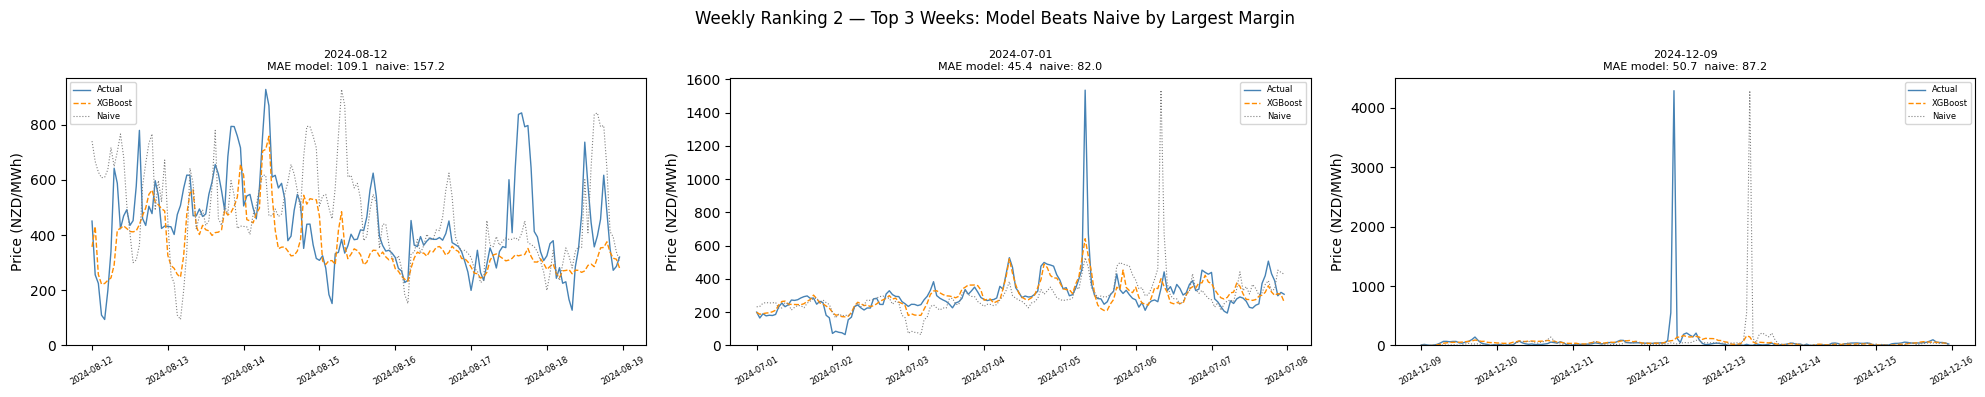

In [93]:
# ══════════════════════════════════════════════════════════════════════════════
# WEEKLY RANKING 2 — TOP 10 WEEKS: Model Beats Naive by Largest Margin
# ══════════════════════════════════════════════════════════════════════════════

beats_w = week_df_results[week_df_results["beats_naive"]].nlargest(10, "naive_advantage")[
    ["week_start", "week_end", "mae_model", "mae_naive", "naive_advantage", "std_actual"]
].reset_index(drop=True)
beats_w.index += 1
print(beats_w.to_string())

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
fig.suptitle("Weekly Ranking 2 — Top 3 Weeks: Model Beats Naive by Largest Margin", fontsize=12)
for i, ax in enumerate(axes):
    ws = beats_w.iloc[i]["week_start"]
    plot_week(ax, ws, str(ws))
plt.tight_layout()
plt.show()

Weeks excluded (max price > 1000): 7  |  Remaining: 45

── TOP 10 WEEKS: Volatile weeks where model was most accurate ──
    week_start    week_end  score_std_per_mae  std_actual  max_actual  mae_model  mae_naive  beats_naive
1   2024-08-26  2024-09-01               2.29      125.84      662.04      54.94      70.91         True
2   2024-08-19  2024-08-25               2.24      127.55      780.87      57.06      84.98         True
3   2024-01-15  2024-01-21               2.19       74.09      496.63      33.83      54.40         True
4   2024-05-27  2024-06-02               2.06       95.96      733.98      46.59      64.81         True
5   2024-12-02  2024-12-08               2.04       41.30      189.63      20.28      30.86         True
6   2024-01-29  2024-02-04               2.03      143.06      794.43      70.37      93.62         True
7   2024-11-04  2024-11-10               2.01       50.39      190.49      25.11      41.78         True
8   2024-03-18  2024-03-24             

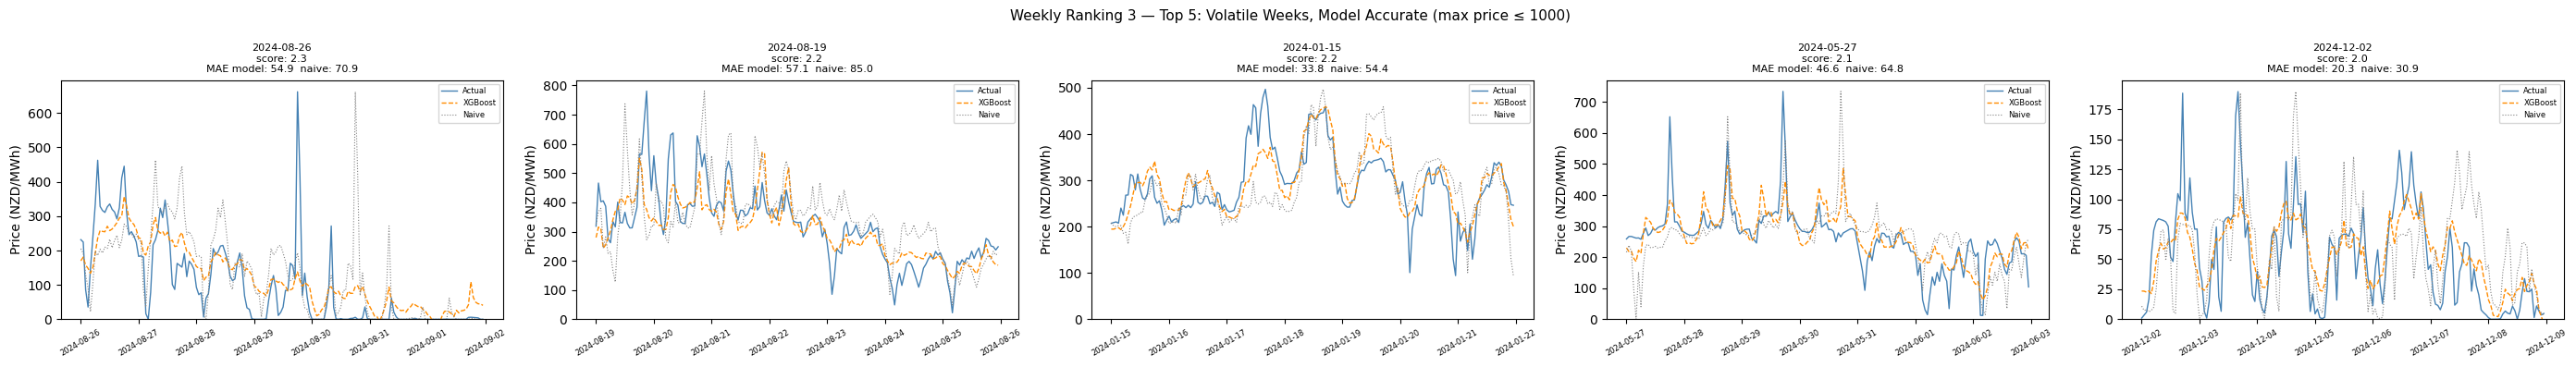

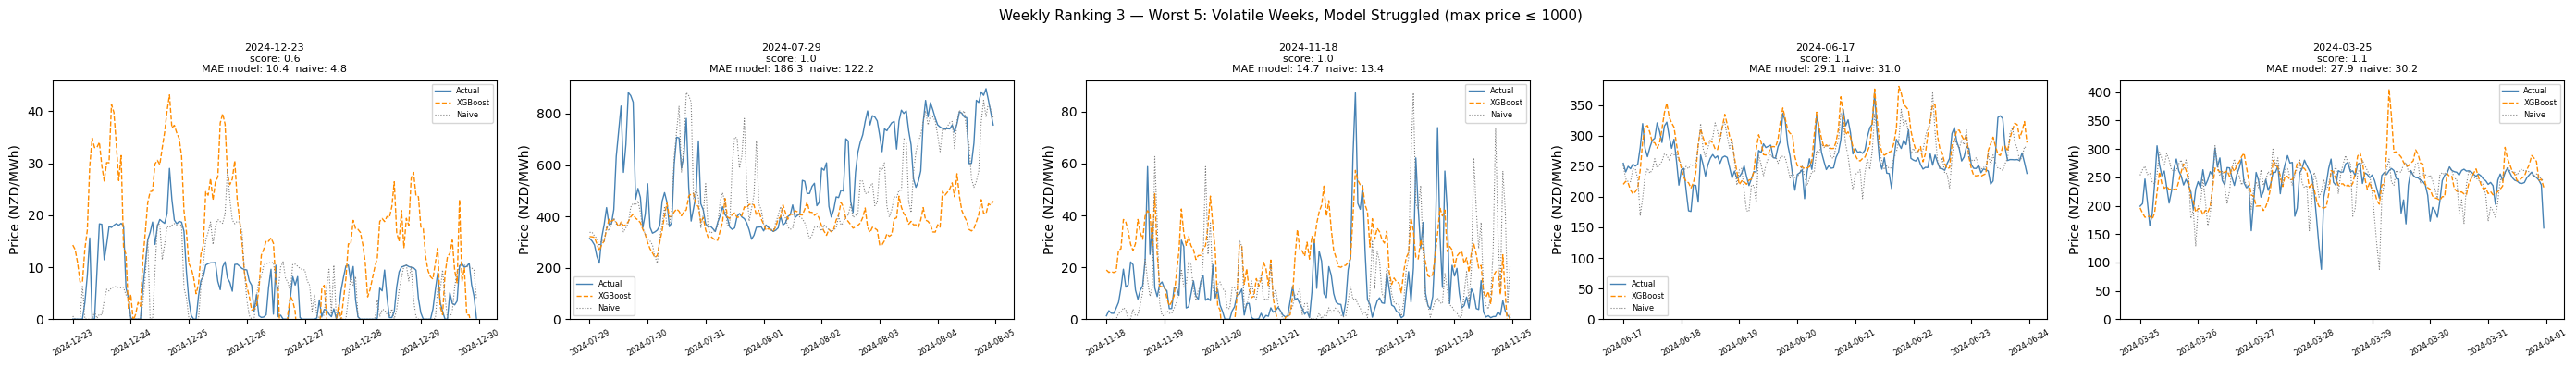


FULL YEAR 2024 — Weekly Summary
  Weeks predicted    : 52
  Avg model MAE      : 49.92 NZD/MWh
  Avg naive MAE      : 56.38 NZD/MWh
  Avg MASE           : 0.887
  Weeks beats naive  : 43 / 52


In [94]:
# ══════════════════════════════════════════════════════════════════════════════
# WEEKLY RANKING 3 — VOLATILE BUT ACCURATE: score = std / model_MAE
# Excludes weeks where any hour exceeded 1000 NZD/MWh
# ══════════════════════════════════════════════════════════════════════════════

SPIKE_EXCLUDE = 1000   # NZD/MWh — same threshold as daily

r3w = week_df_results[week_df_results["max_actual"] <= SPIKE_EXCLUDE].copy()
excluded_w = len(week_df_results) - len(r3w)
print(f"Weeks excluded (max price > {SPIKE_EXCLUDE}): {excluded_w}  |  Remaining: {len(r3w)}\n")

top_score_w   = r3w.nlargest(10,  "score_std_per_mae")
worst_score_w = r3w.nsmallest(10, "score_std_per_mae")

cols_show_w = ["week_start", "week_end", "score_std_per_mae", "std_actual", "max_actual", "mae_model", "mae_naive", "beats_naive"]

print("── TOP 10 WEEKS: Volatile weeks where model was most accurate ──")
ts_w = top_score_w[cols_show_w].reset_index(drop=True)
ts_w.index += 1
print(ts_w.to_string())

print("\n── WORST 10 WEEKS: Volatile weeks where model struggled most ──")
ws_w = worst_score_w[cols_show_w].reset_index(drop=True)
ws_w.index += 1
print(ws_w.to_string())

fig, axes = plt.subplots(1, 5, figsize=(28, 4))
fig.suptitle(f"Weekly Ranking 3 — Top 5: Volatile Weeks, Model Accurate (max price ≤ {SPIKE_EXCLUDE})", fontsize=11)
for i, ax in enumerate(axes):
    ws    = top_score_w.iloc[i]["week_start"]
    score = top_score_w.iloc[i]["score_std_per_mae"]
    plot_week(ax, ws, f"{ws}\nscore: {score:.1f}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(28, 4))
fig.suptitle(f"Weekly Ranking 3 — Worst 5: Volatile Weeks, Model Struggled (max price ≤ {SPIKE_EXCLUDE})", fontsize=11)
for i, ax in enumerate(axes):
    ws    = worst_score_w.iloc[i]["week_start"]
    score = worst_score_w.iloc[i]["score_std_per_mae"]
    plot_week(ax, ws, f"{ws}\nscore: {score:.1f}")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FULL YEAR 2024 — Weekly Summary")
print("=" * 60)
print(f"  Weeks predicted    : {len(week_df_results)}")
print(f"  Avg model MAE      : {week_df_results['mae_model'].mean():.2f} NZD/MWh")
print(f"  Avg naive MAE      : {week_df_results['mae_naive'].mean():.2f} NZD/MWh")
print(f"  Avg MASE           : {(week_df_results['mae_model'] / week_df_results['mae_naive']).mean():.3f}")
print(f"  Weeks beats naive  : {week_df_results['beats_naive'].sum()} / {len(week_df_results)}")

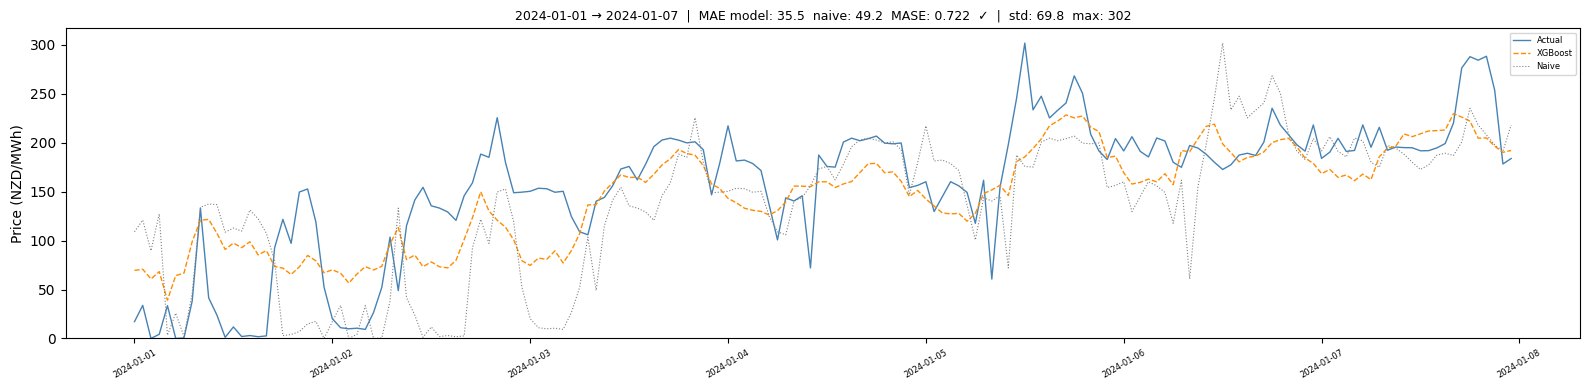

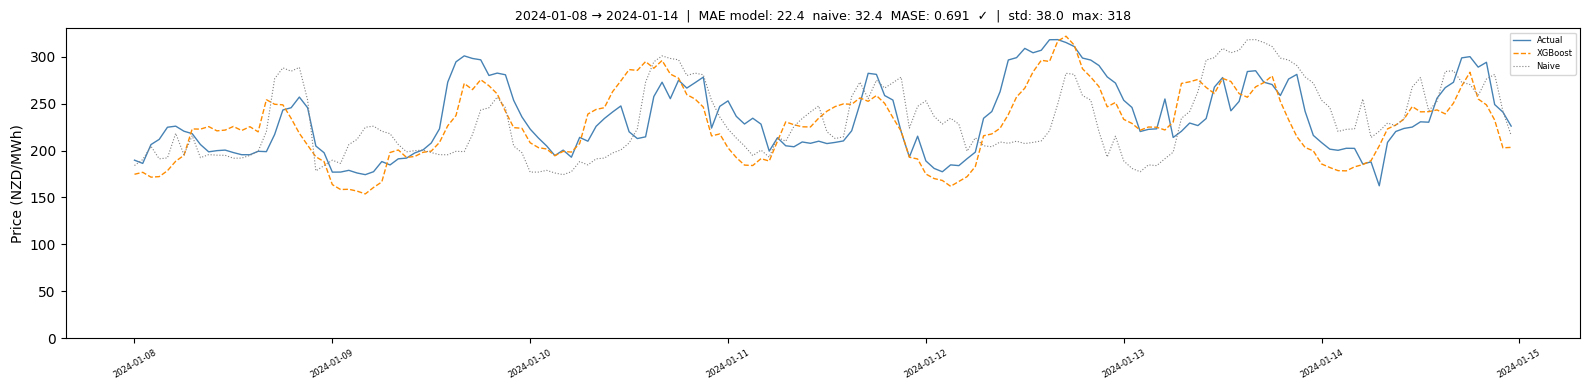

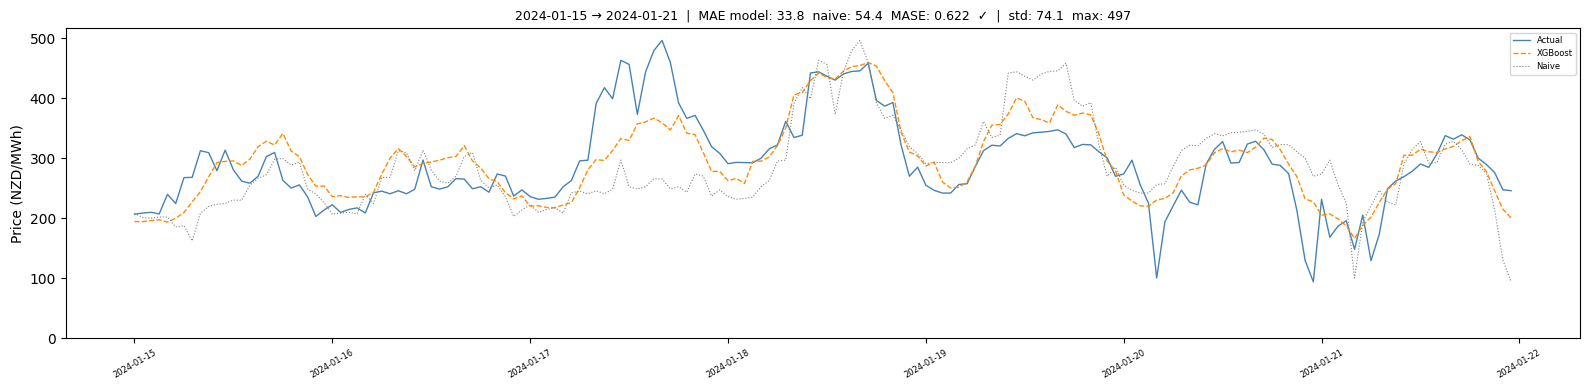

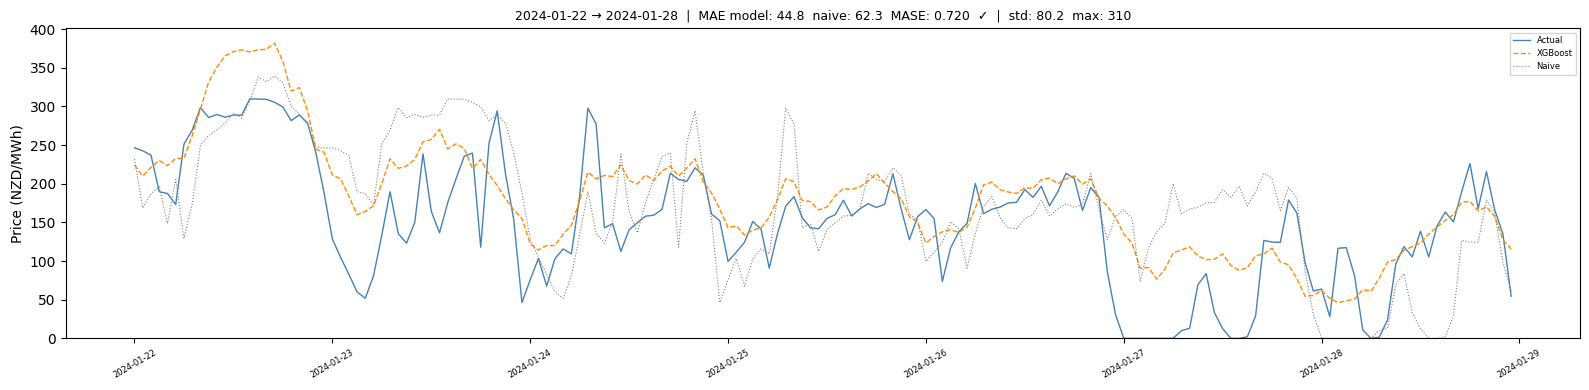

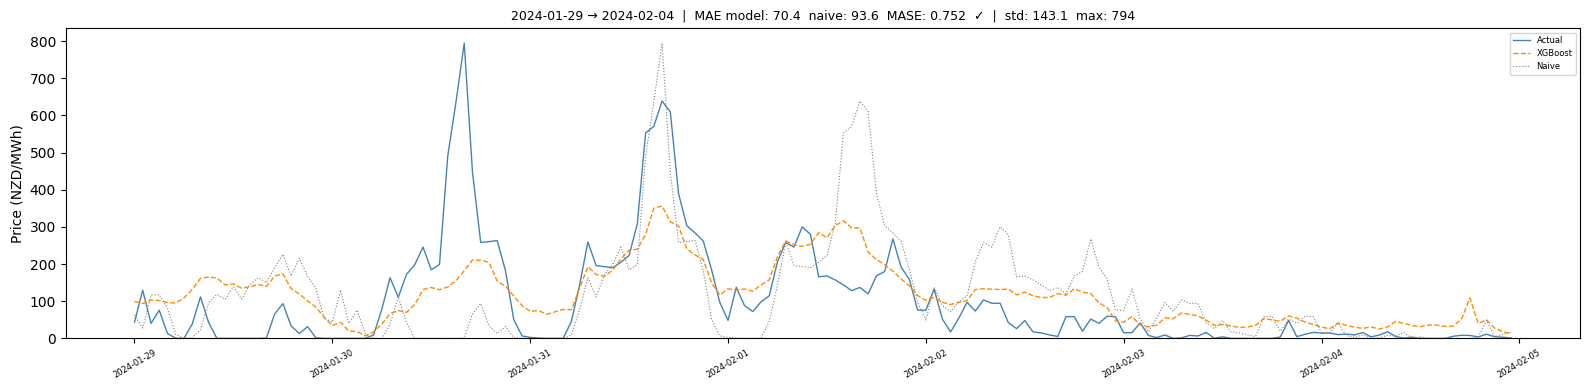

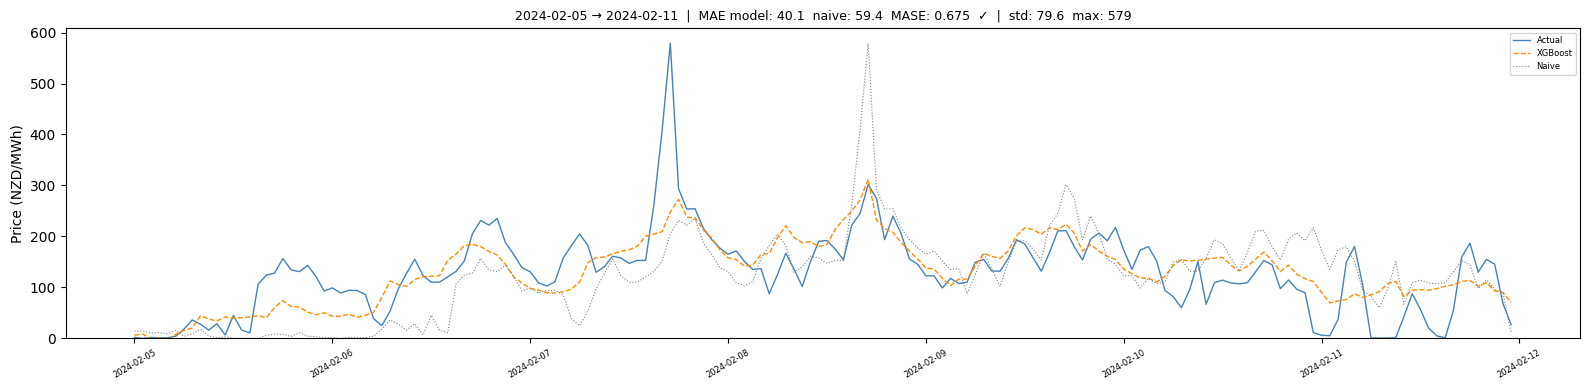

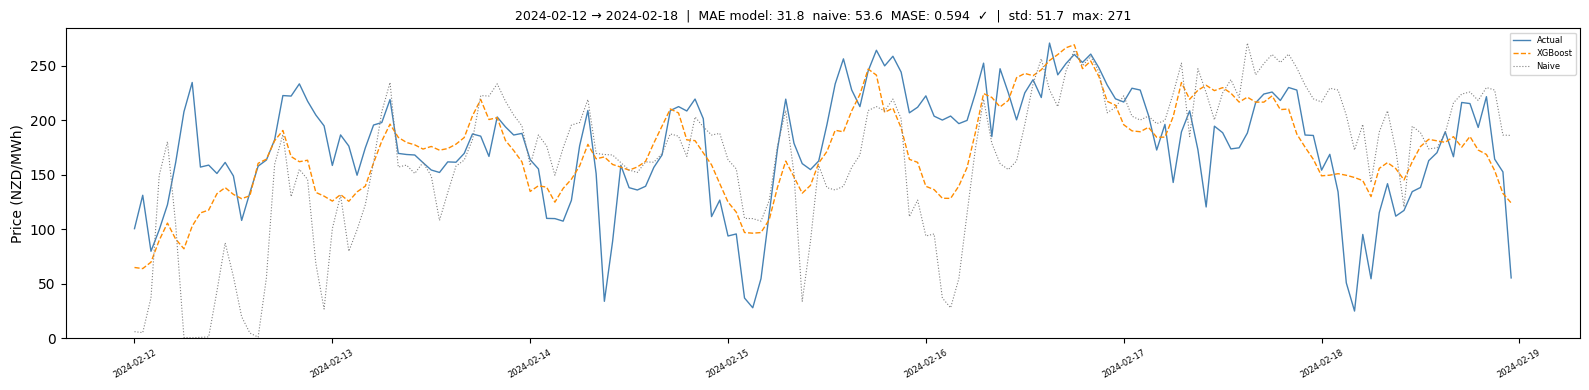

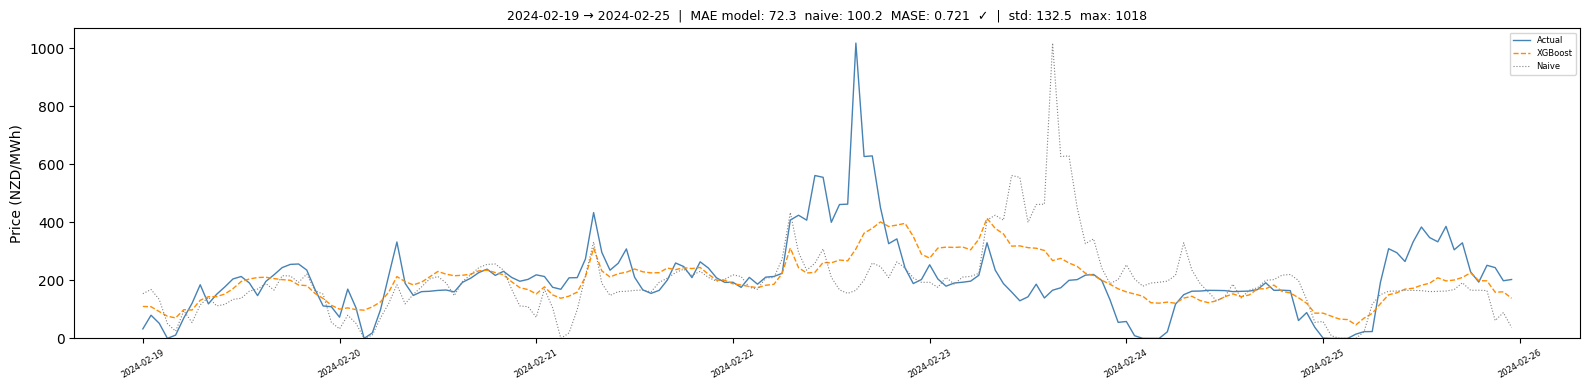

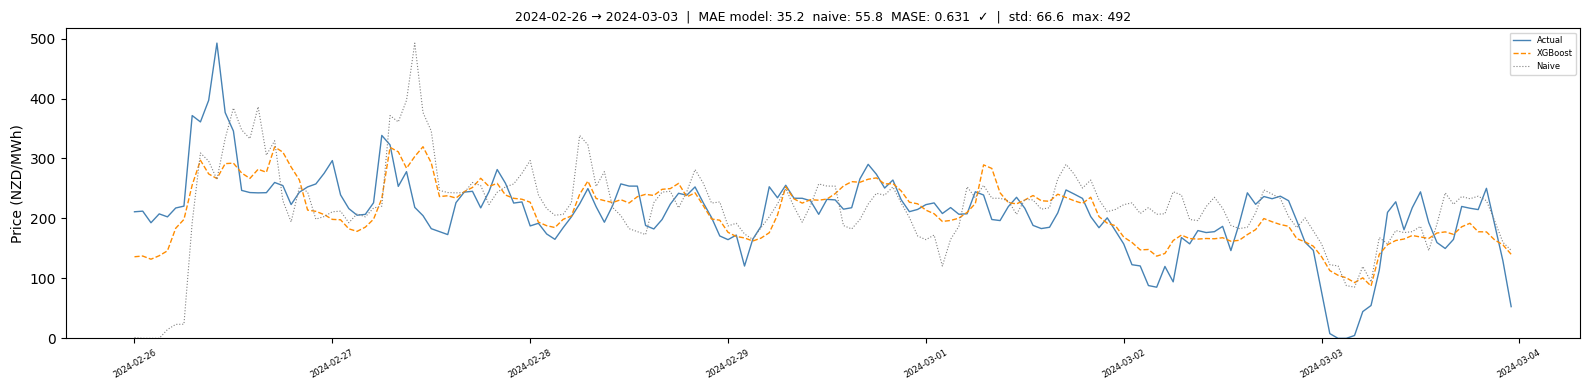

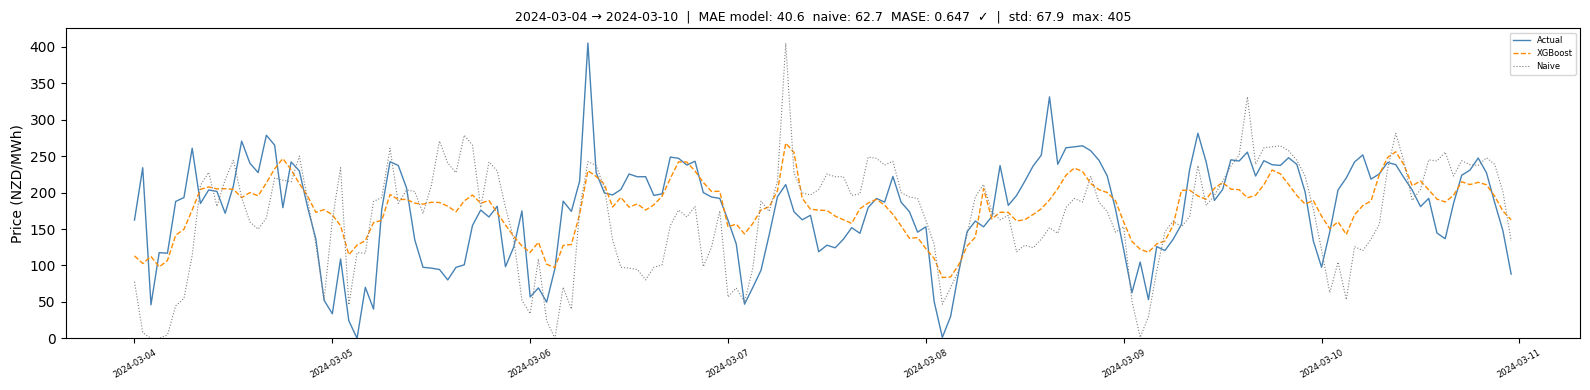

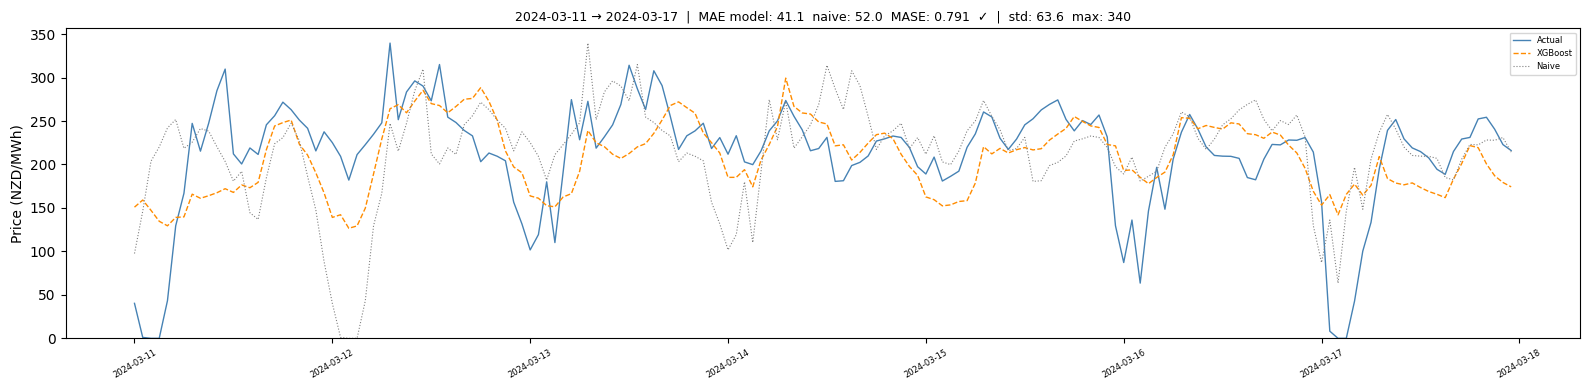

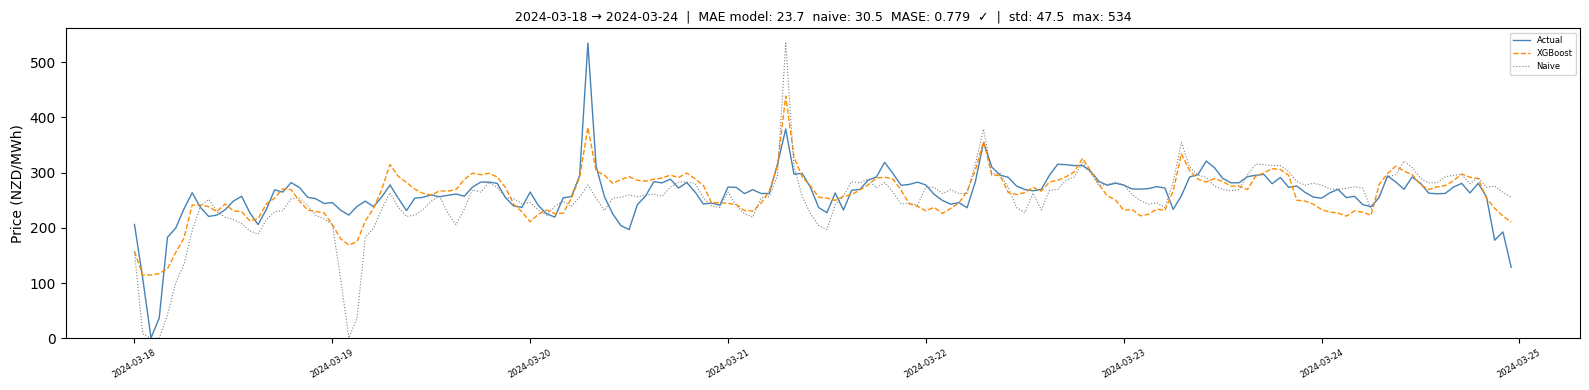

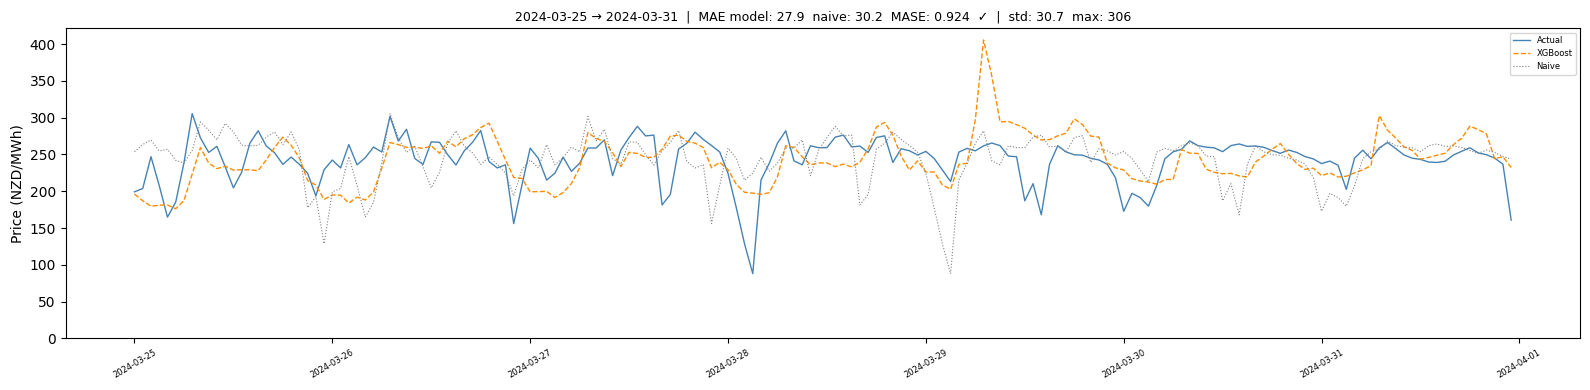

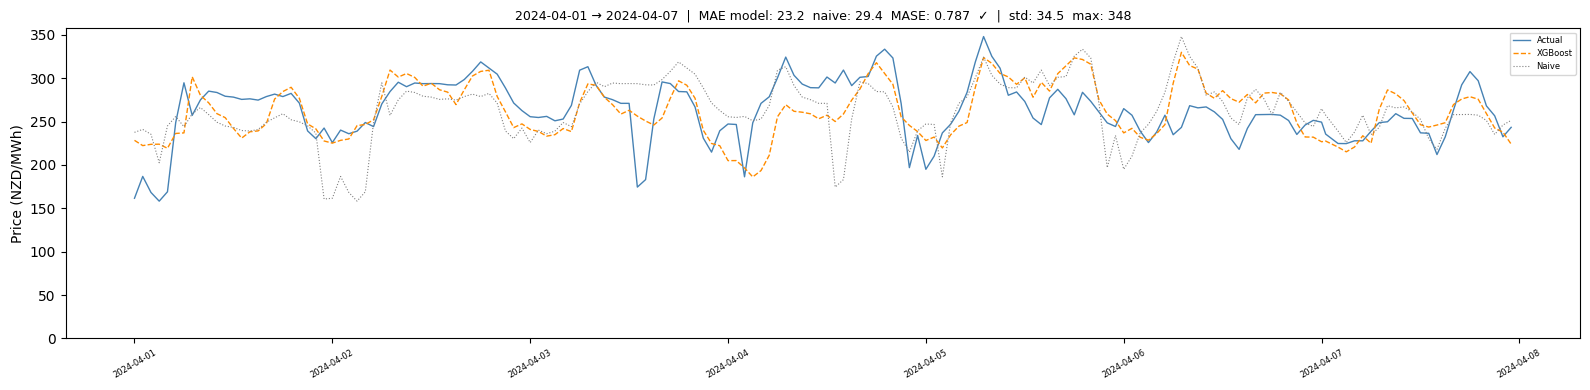

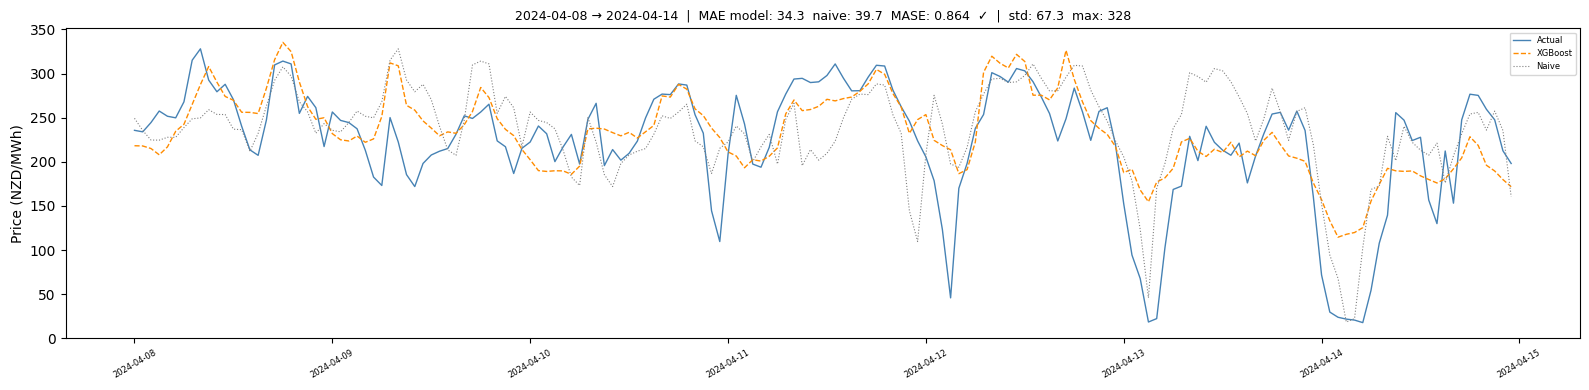

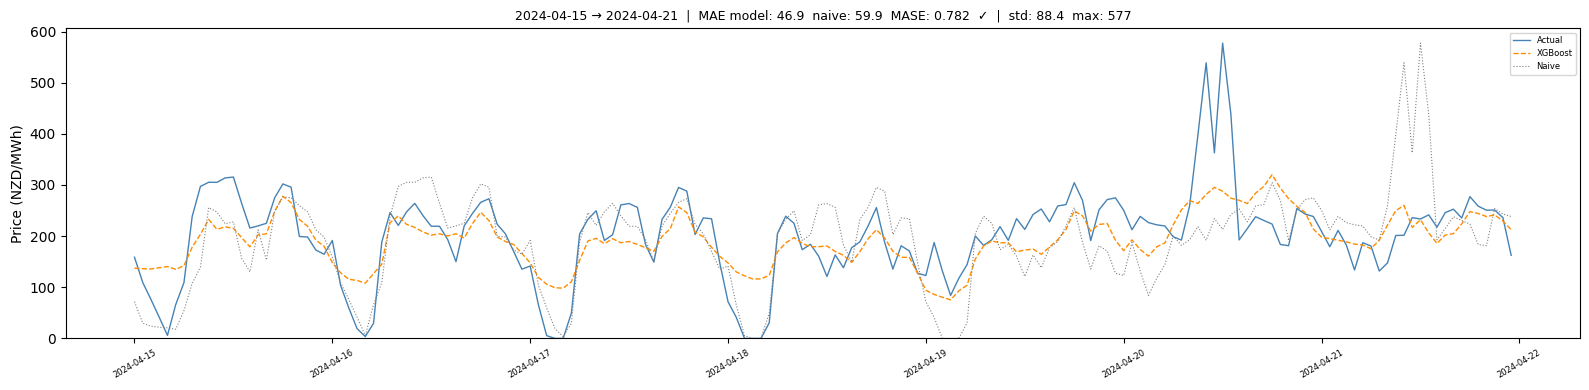

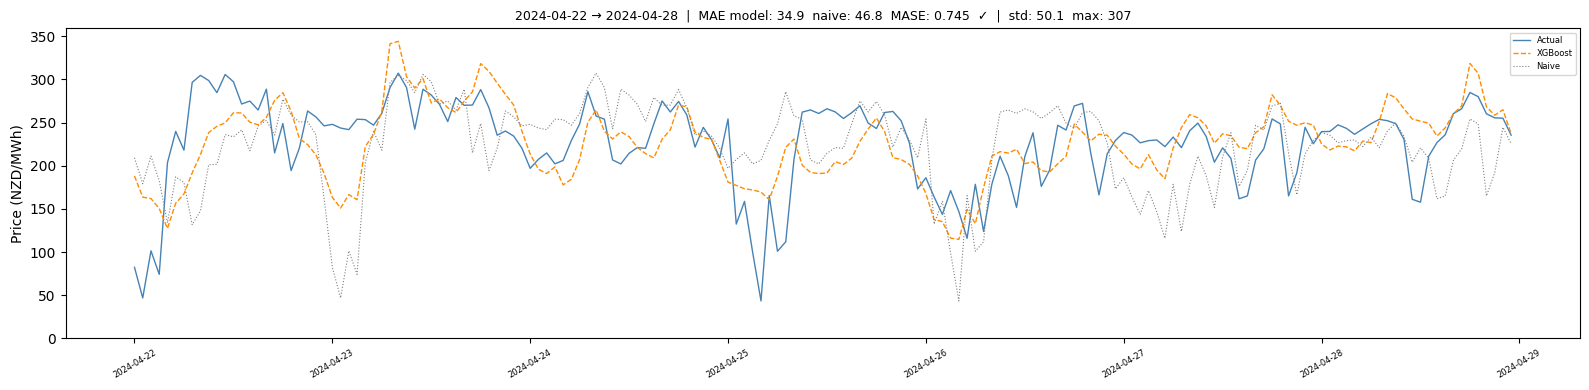

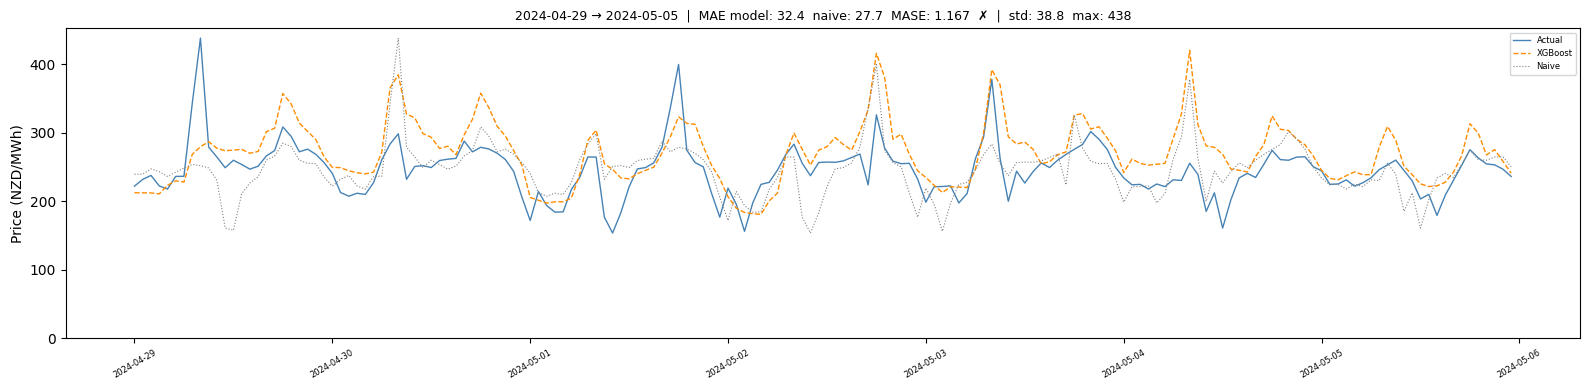

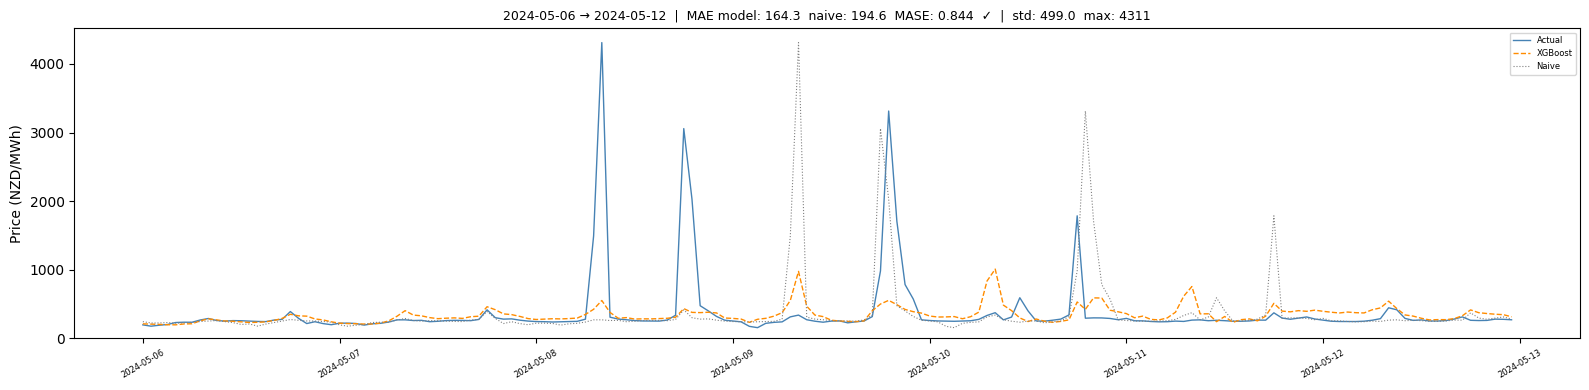

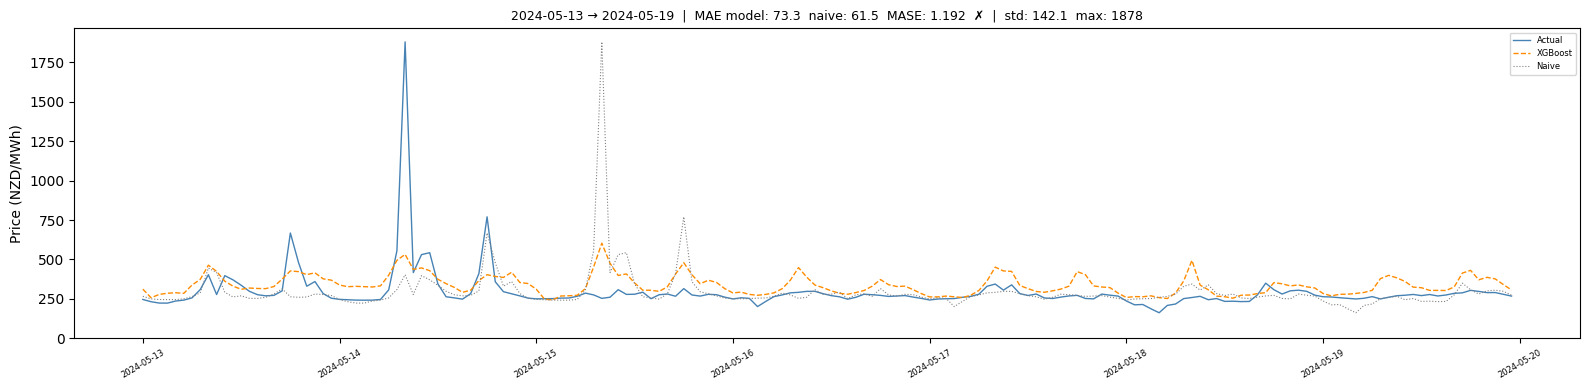

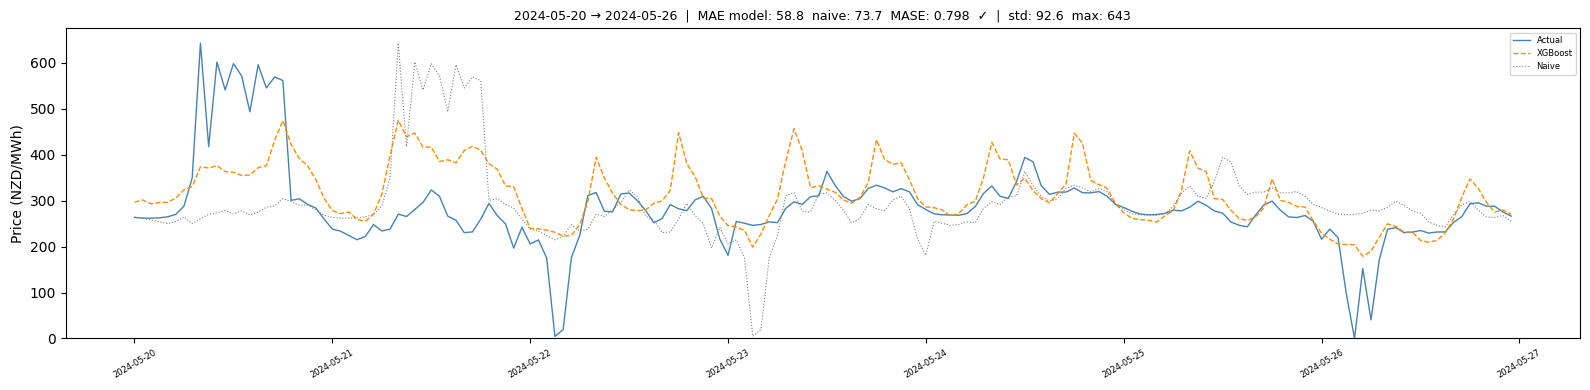

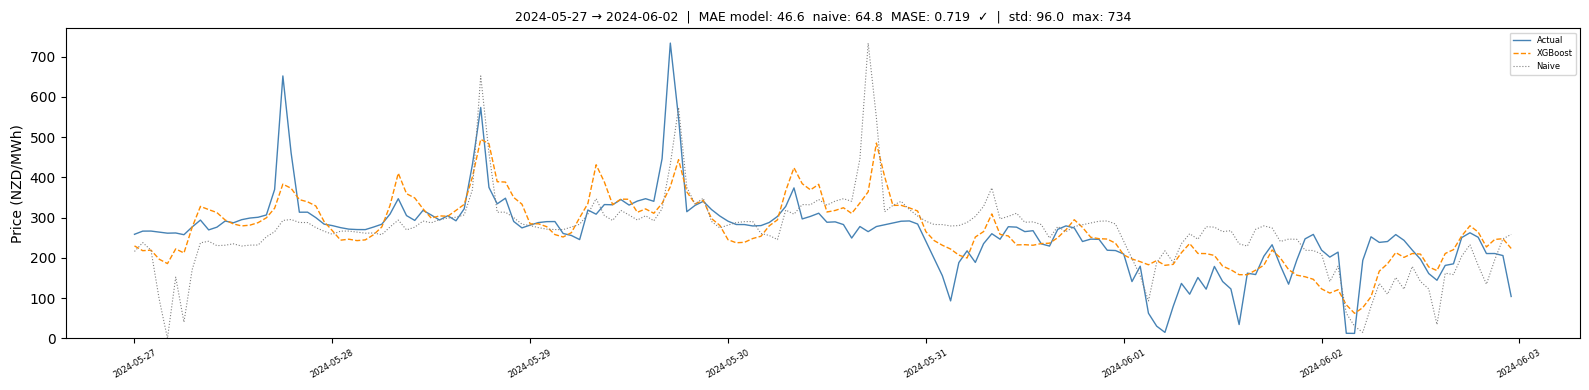

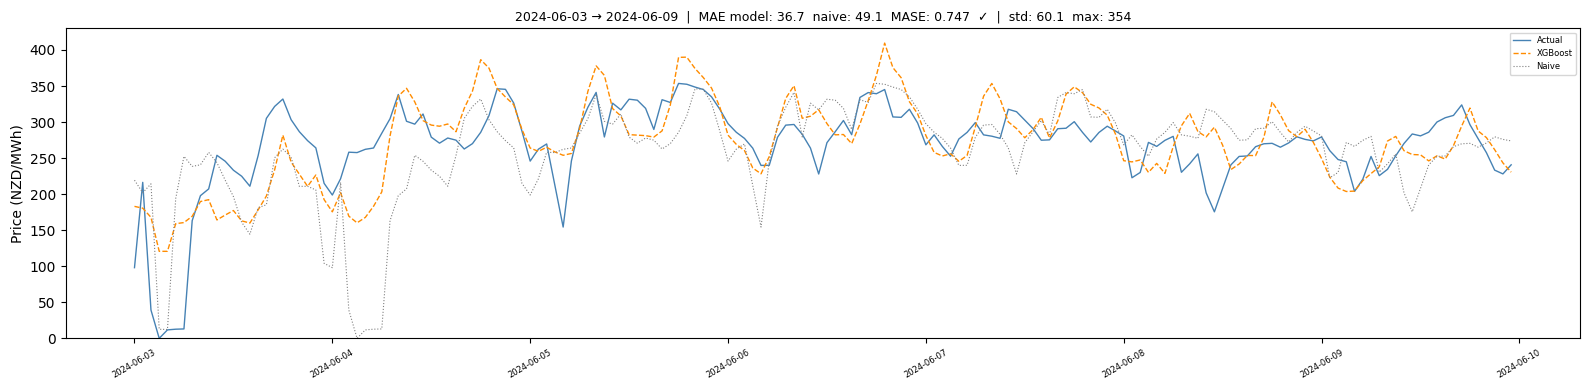

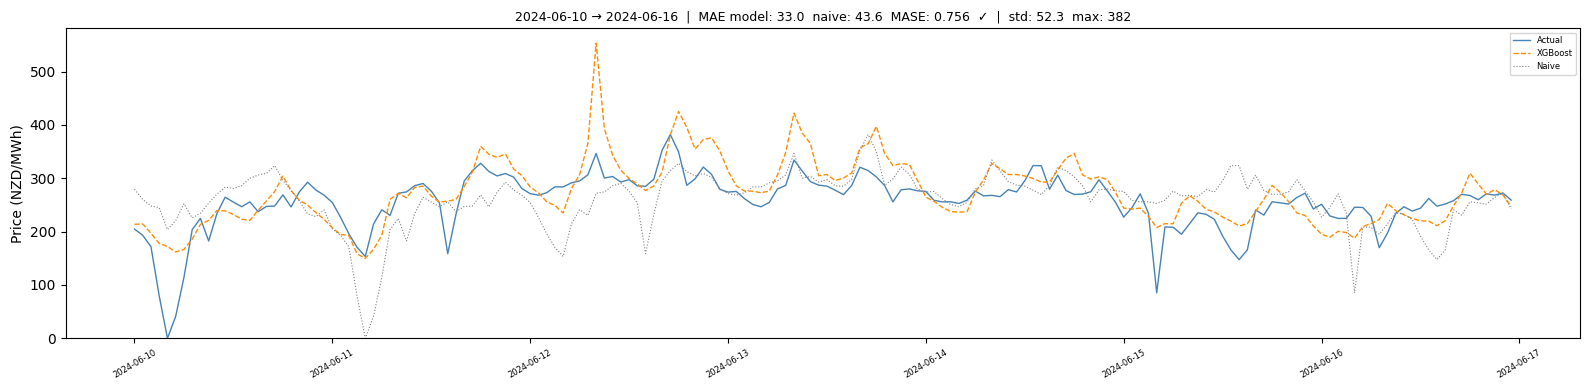

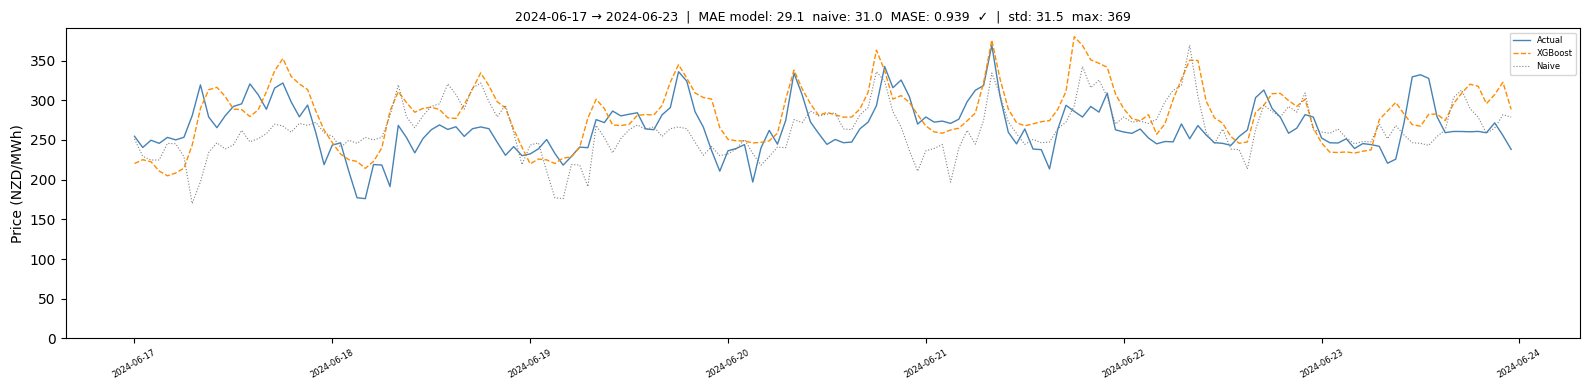

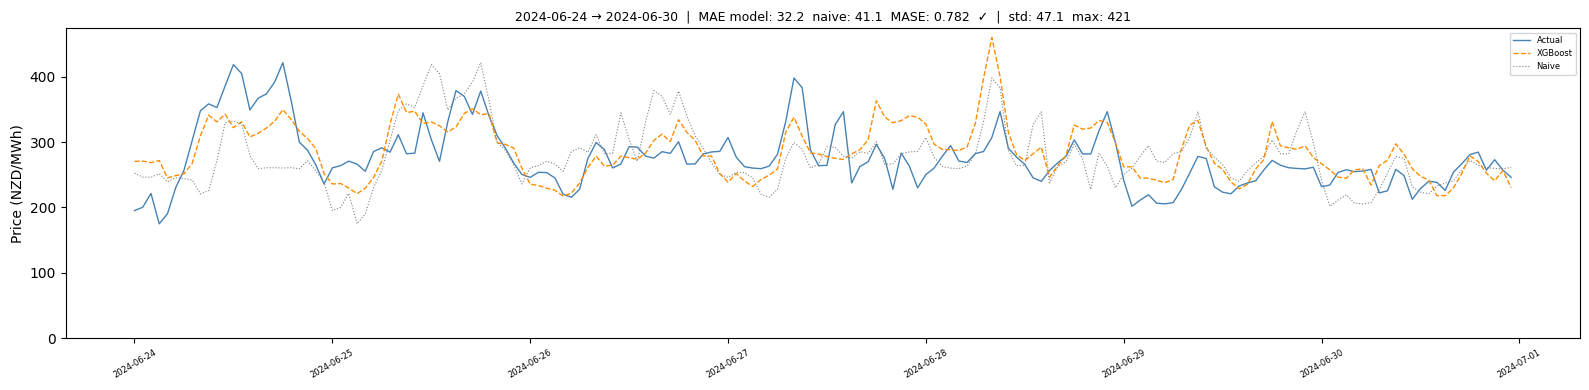

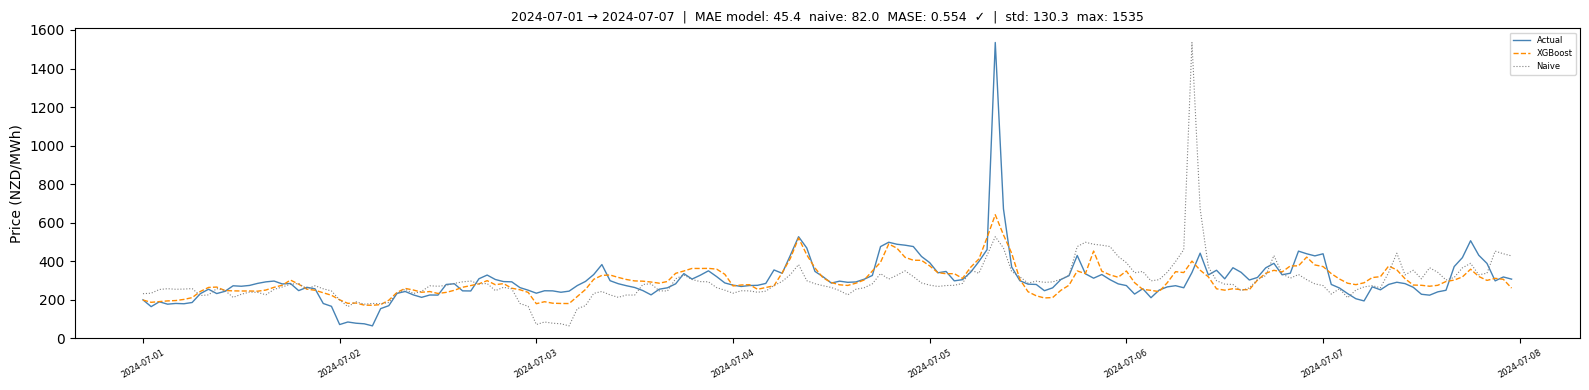

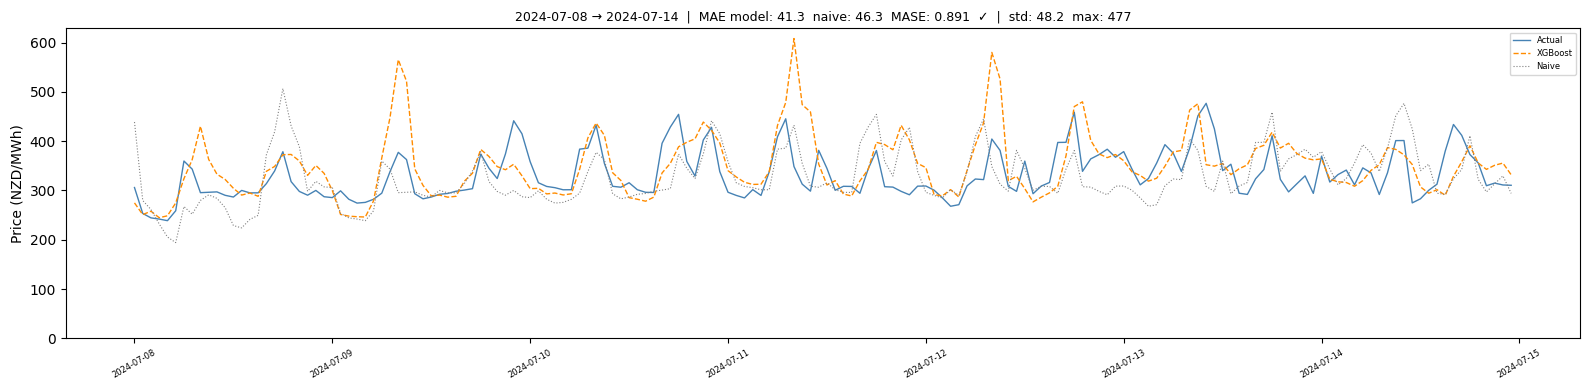

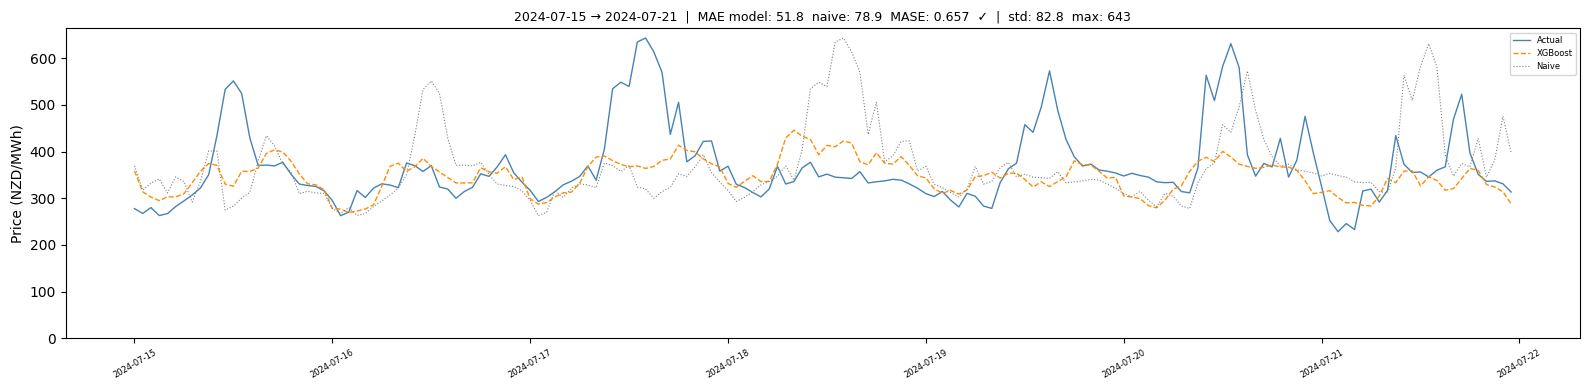

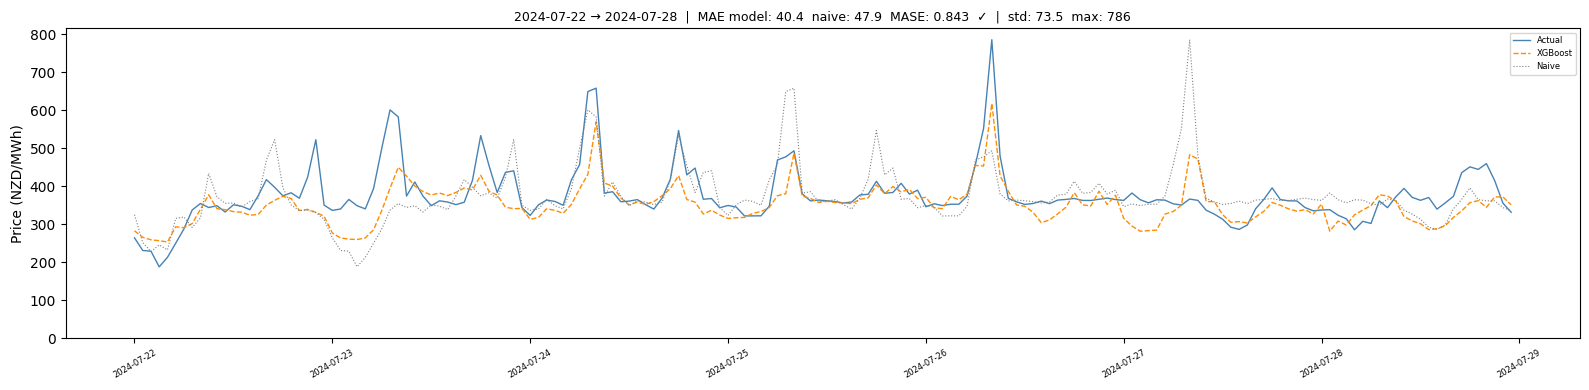

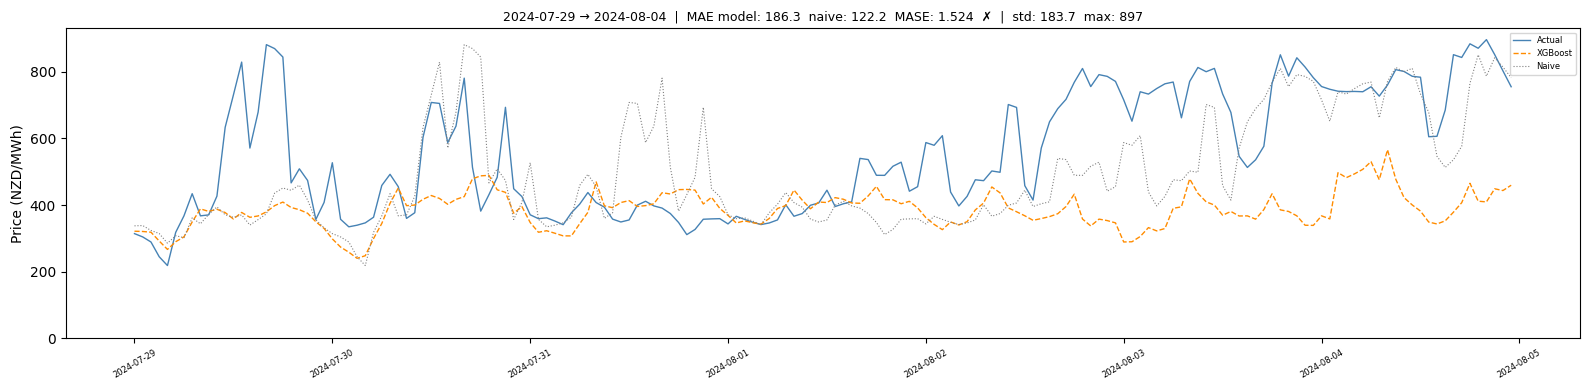

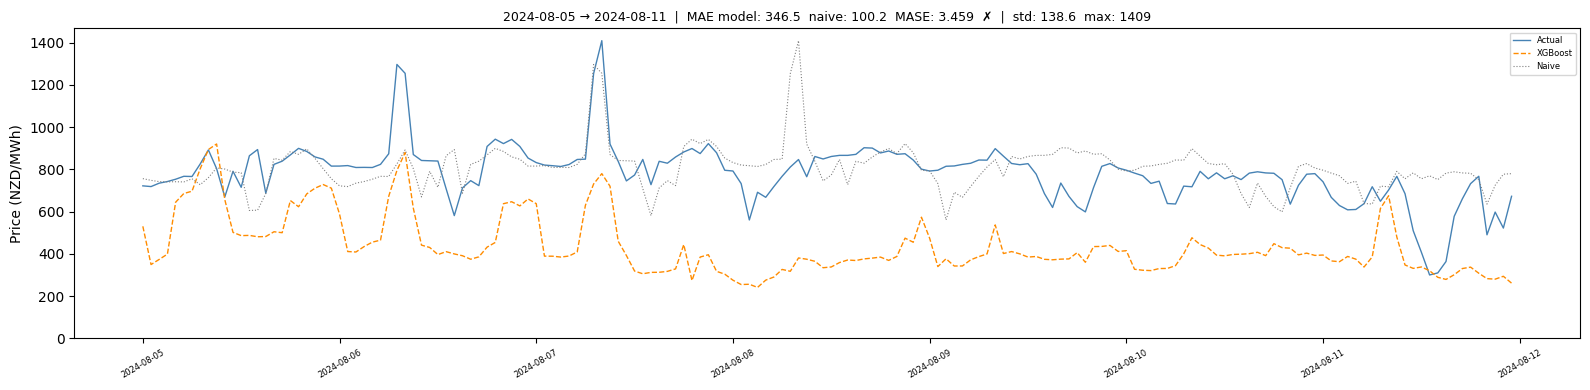

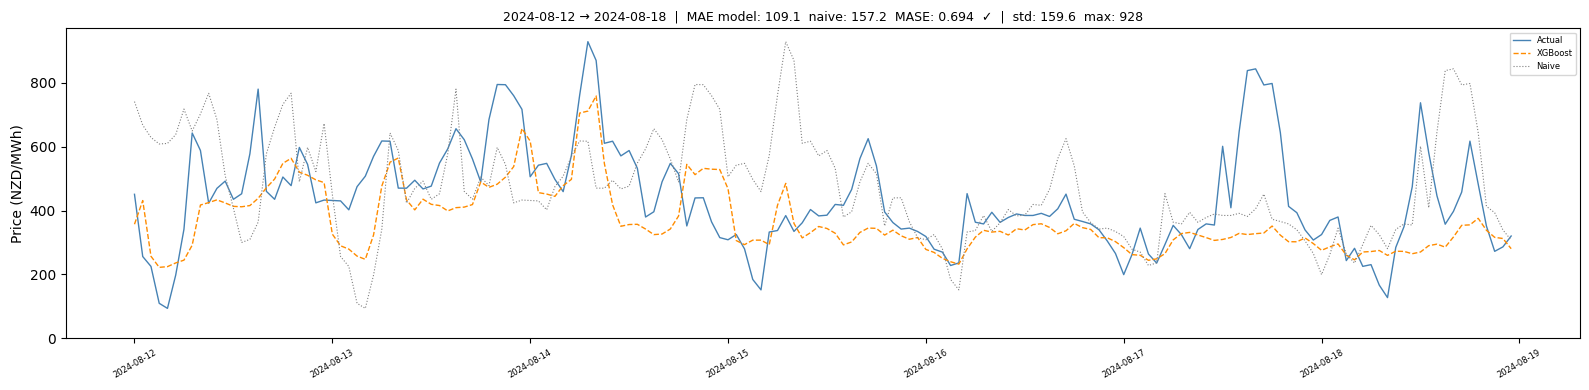

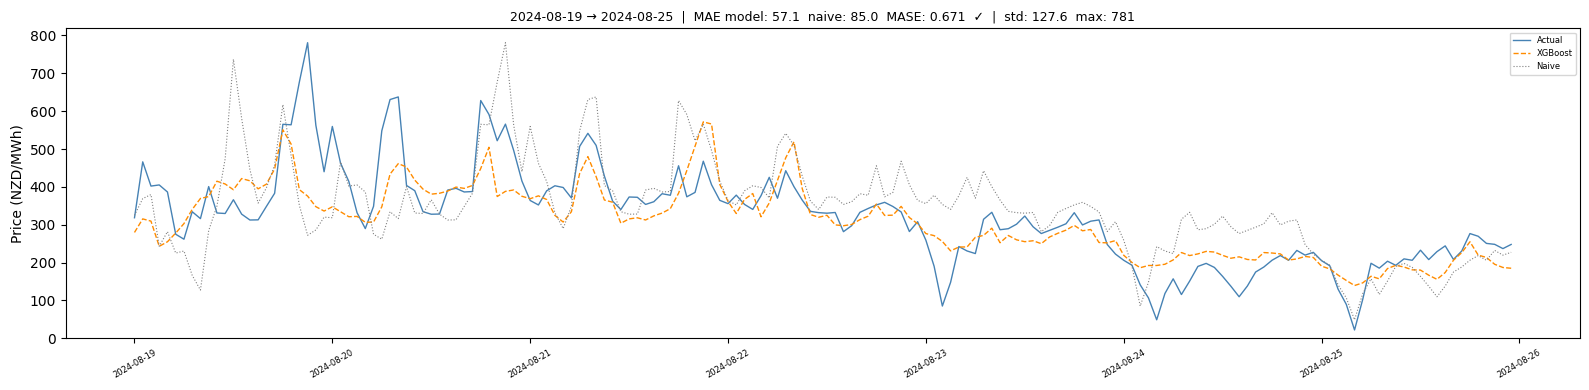

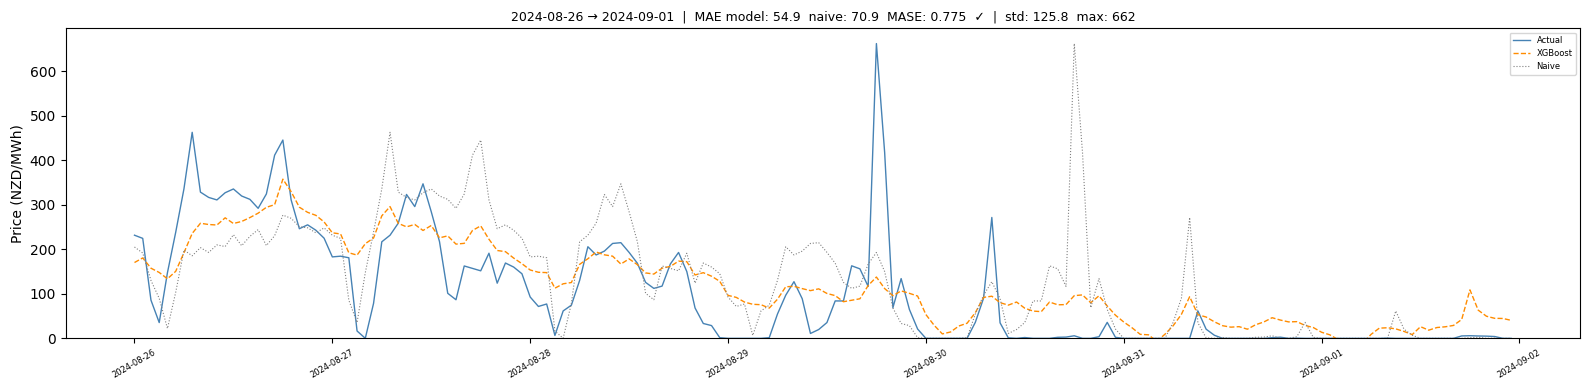

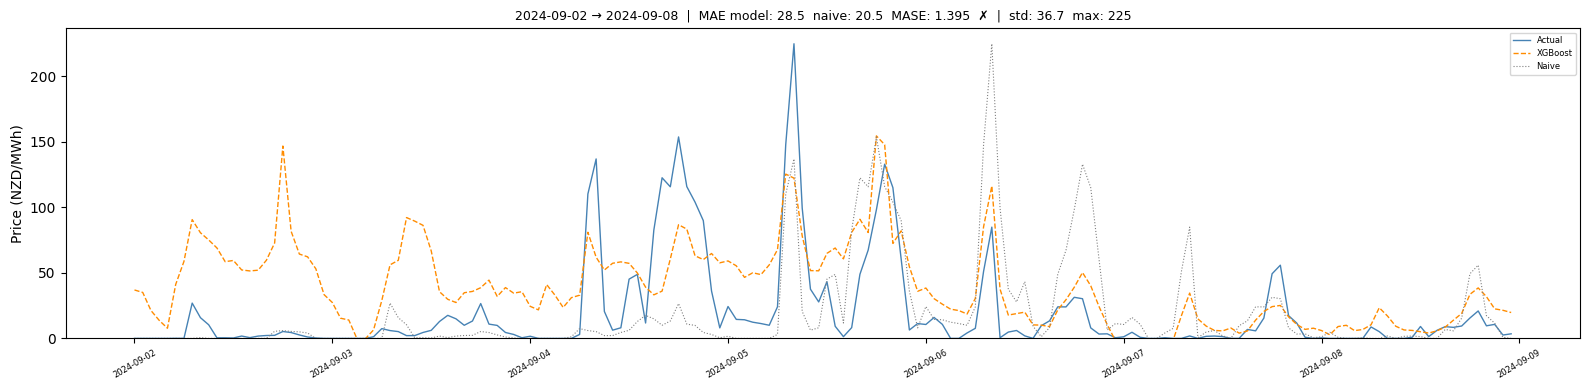

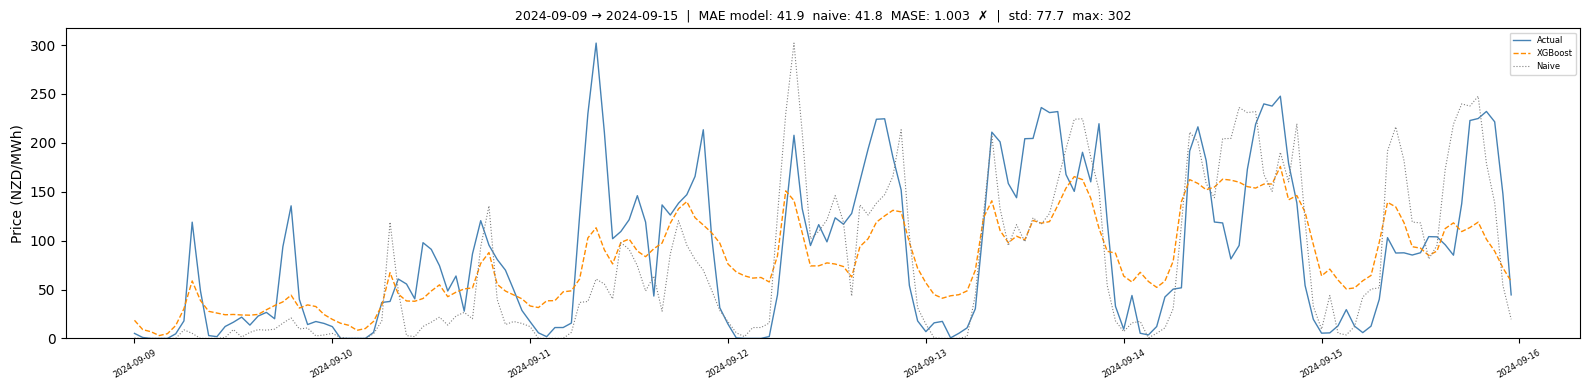

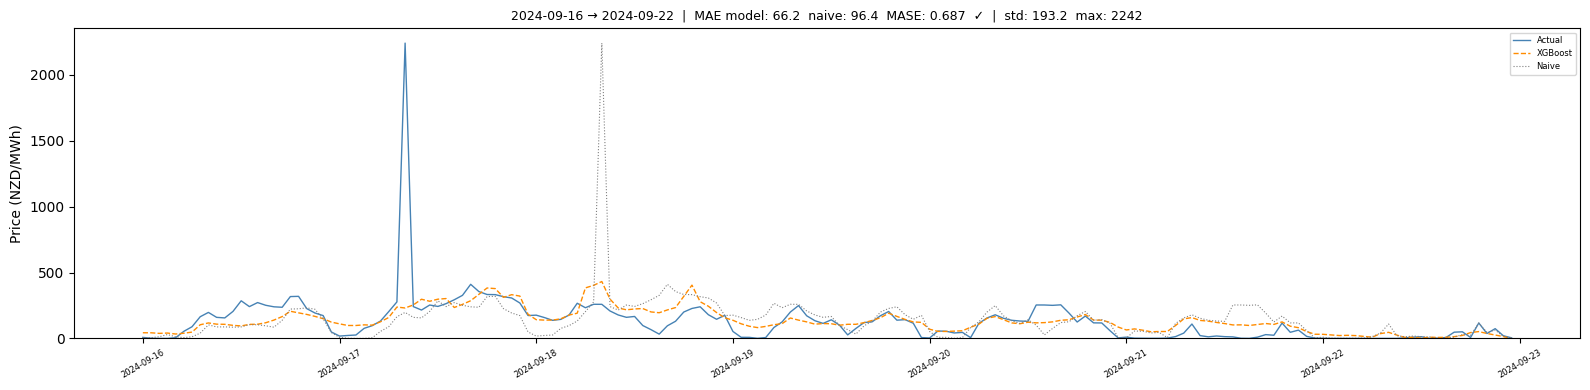

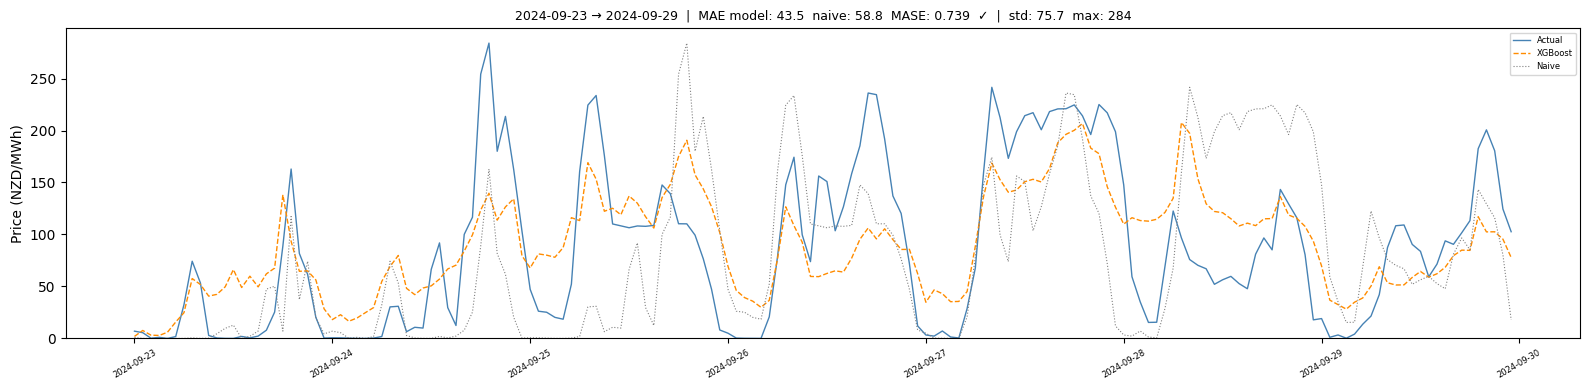

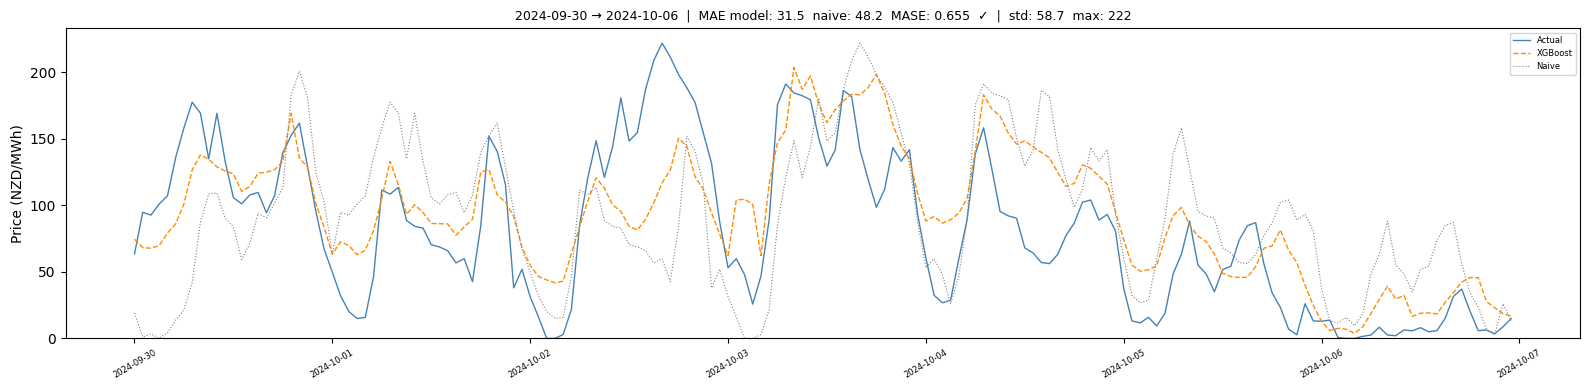

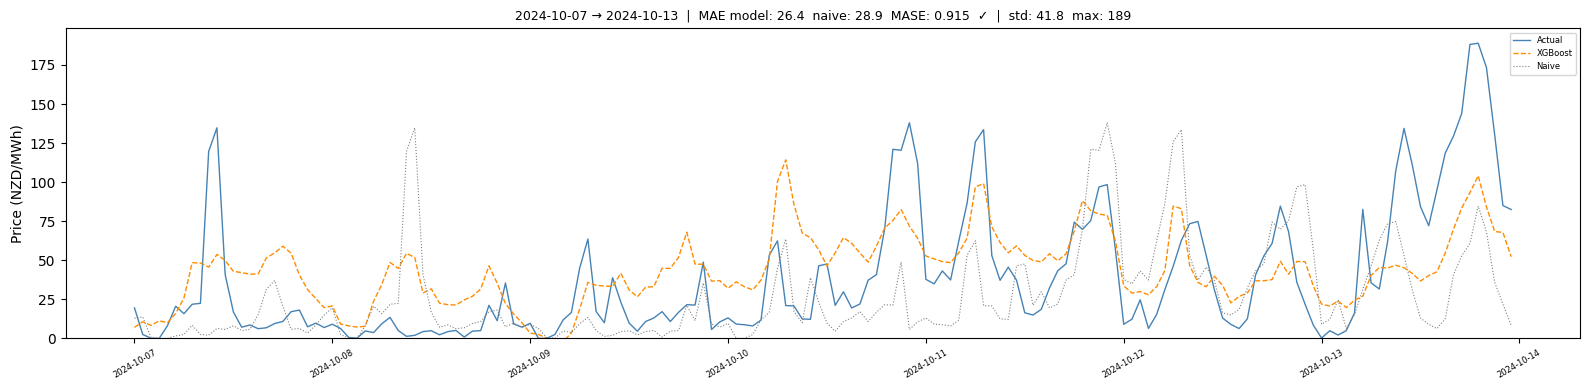

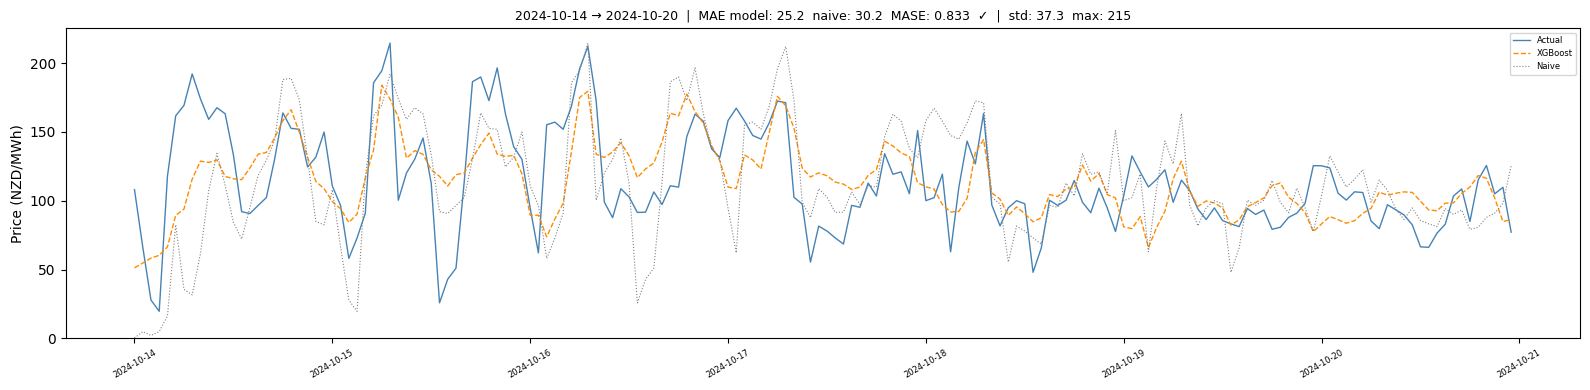

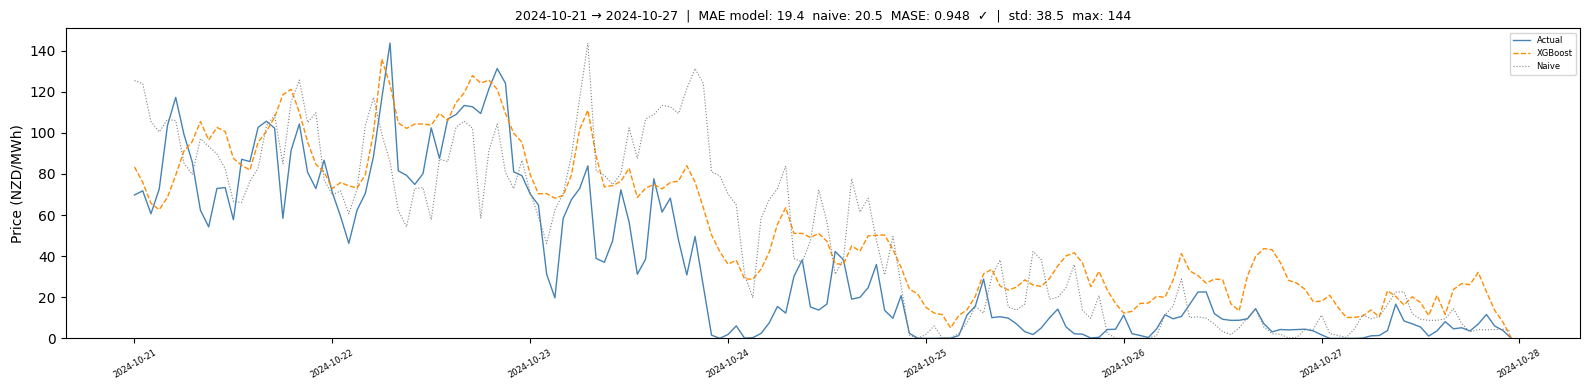

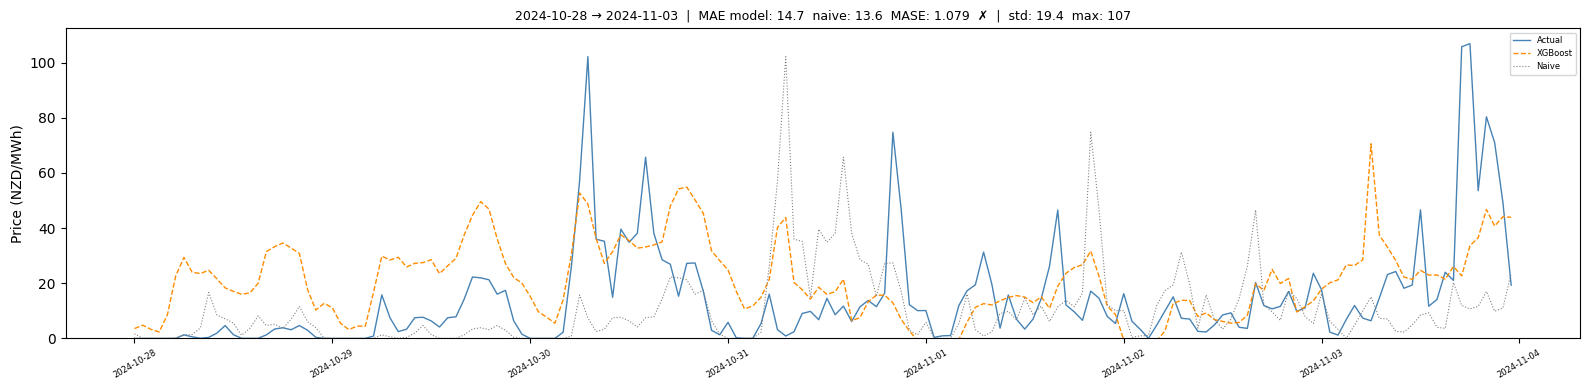

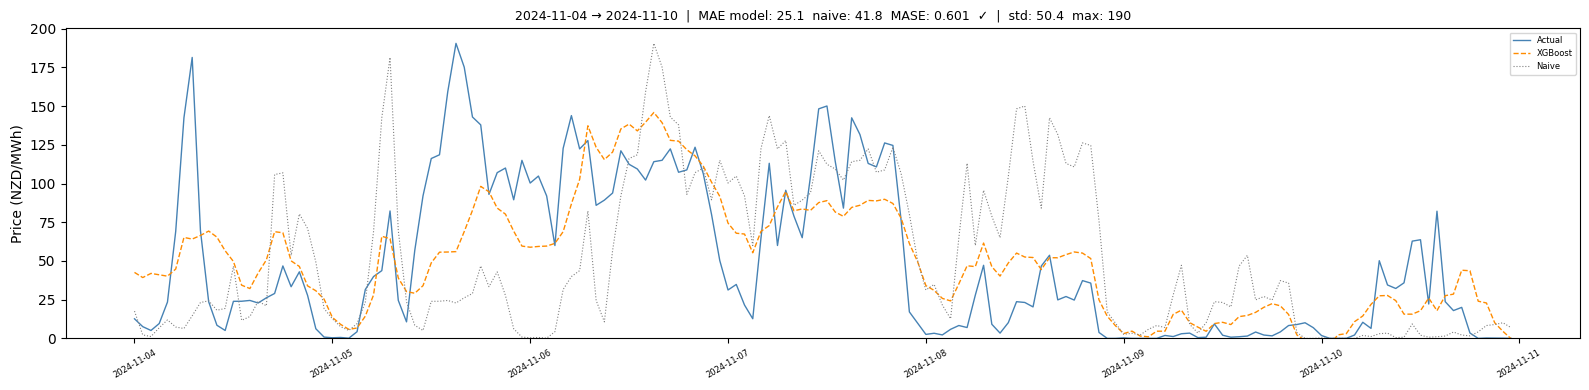

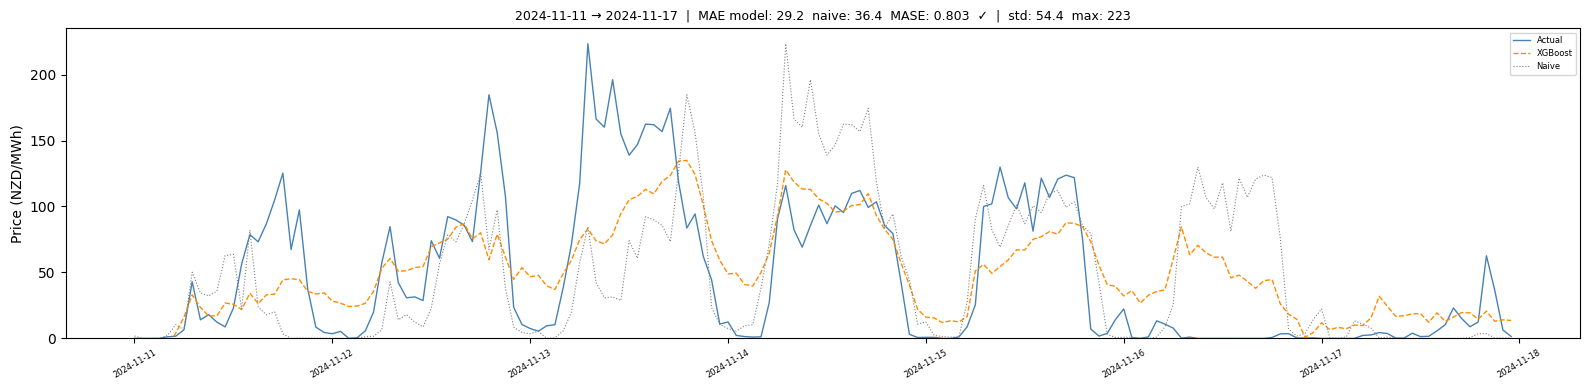

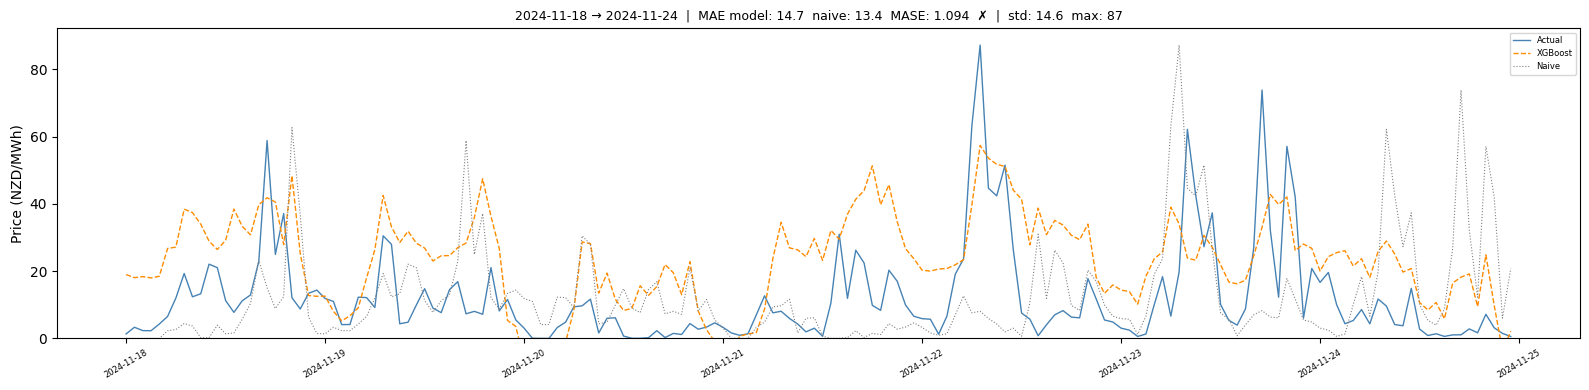

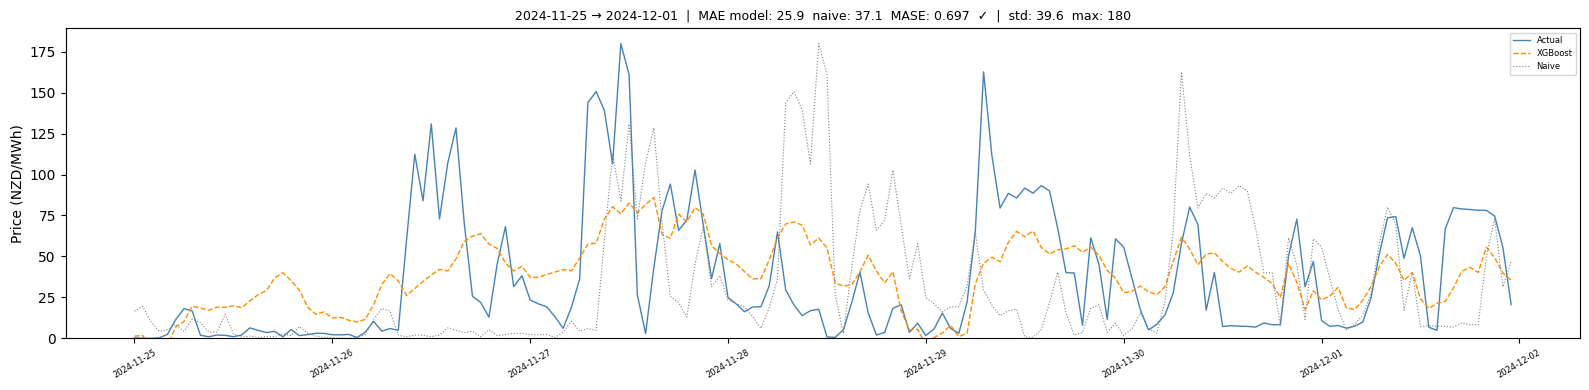

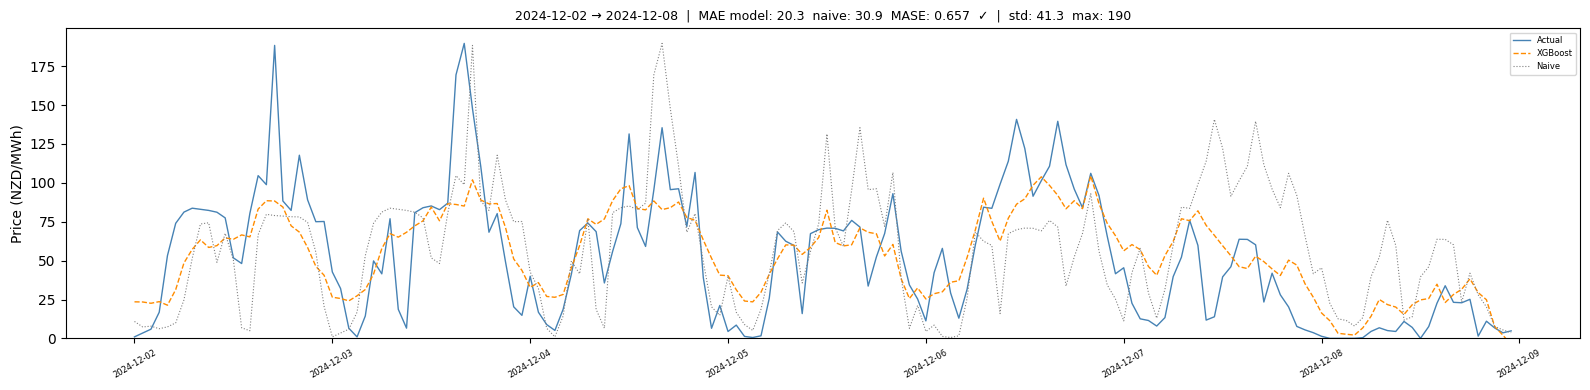

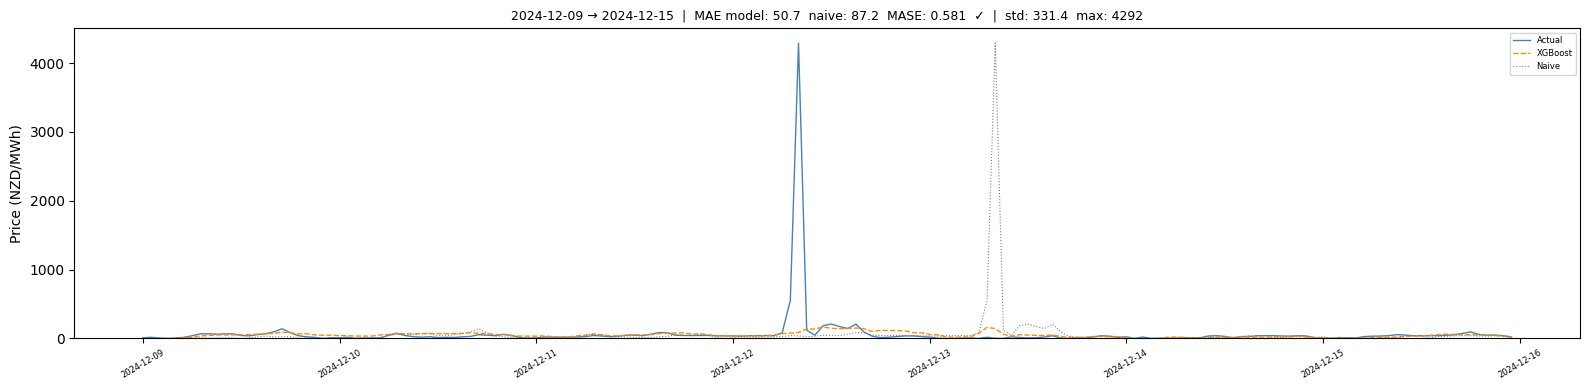

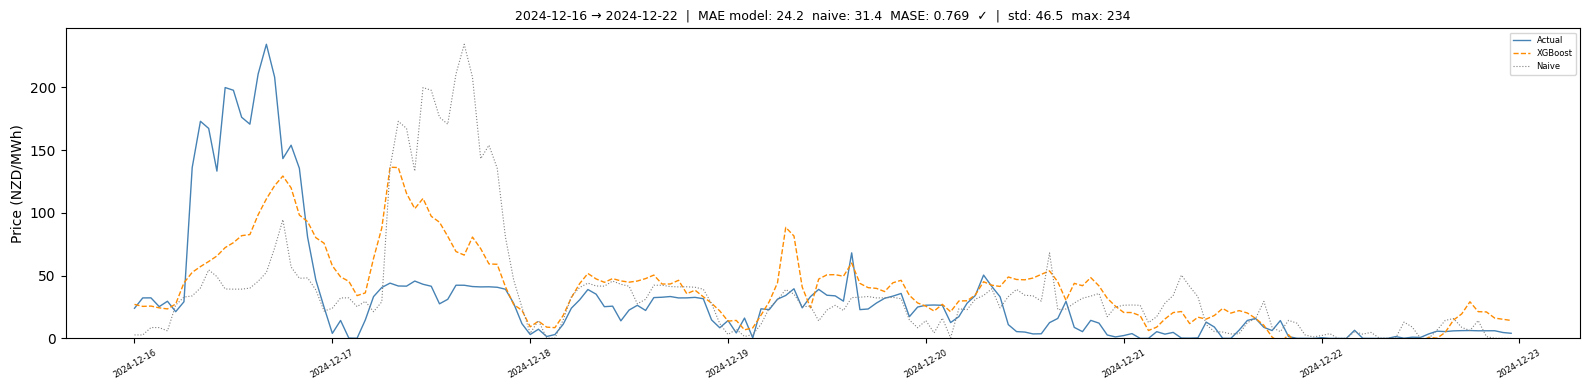

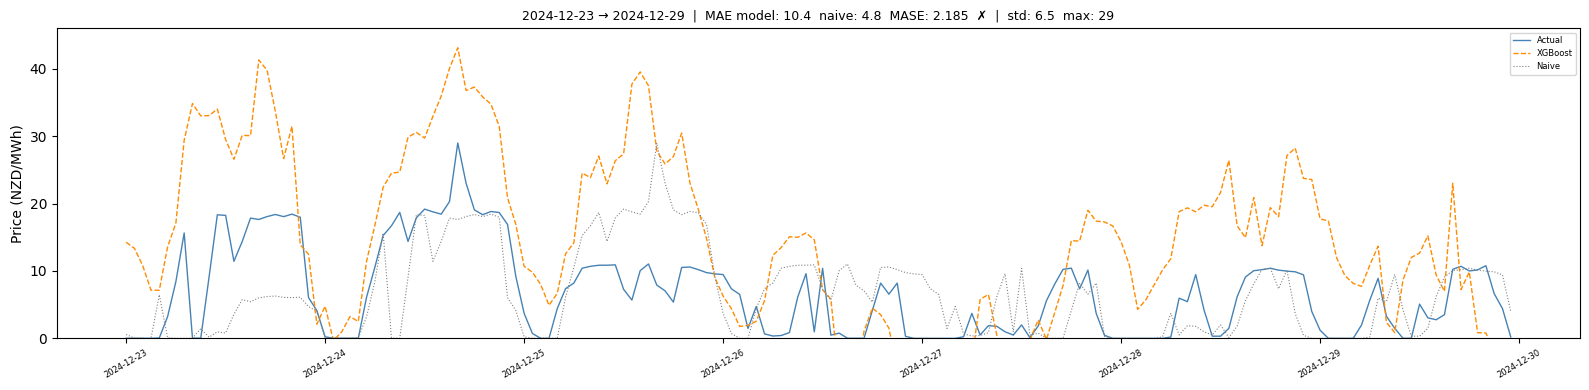

In [95]:
# ══════════════════════════════════════════════════════════════════════════════
# ALL 52 WEEKS OF 2024 — One plot per week
# ══════════════════════════════════════════════════════════════════════════════

for _, row in week_df_results.iterrows():
    ws    = row["week_start"]
    we    = row["week_end"]
    mae_m = row["mae_model"]
    mae_n = row["mae_naive"]
    mase  = mae_m / mae_n
    flag  = "✓" if row["beats_naive"] else "✗"

    fig, ax = plt.subplots(figsize=(16, 4))
    plot_week(ax, ws, f"{ws} → {we}")
    ax.set_title(
        f"{ws} → {we}  |  "
        f"MAE model: {mae_m:.1f}  naive: {mae_n:.1f}  "
        f"MASE: {mase:.3f}  {flag}  |  "
        f"std: {row['std_actual']:.1f}  max: {row['max_actual']:.0f}",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()

Daily energy required : 0.24 MWh
Machine power         : 0.03 MW
Consumption hours/day : 8h  (0.03 MW × 8h = 0.2 MWh/day)

────────────────────────────────────────────────────
Date            Model (NZD)  Naive (NZD)  Uniform (NZD)
────────────────────────────────────────────────────
2024-07-04            69.67        67.80          86.55
2024-07-05            69.14        74.21          88.92
2024-07-06            71.79        82.55          79.21
2024-07-07            56.96        63.93          76.93
2024-07-08            64.16        67.80          72.70
2024-07-09            68.79        71.96          77.11
2024-07-10            72.78        74.96          83.91
────────────────────────────────────────────────────
TOTAL                473.29       503.22         565.33

Savings vs uniform — Model: 92.05 NZD  (16.3%)
Savings vs uniform — Naive: 62.11 NZD  (11.0%)
Model vs Naive     — Model saves: 29.93 NZD  (5.9%)


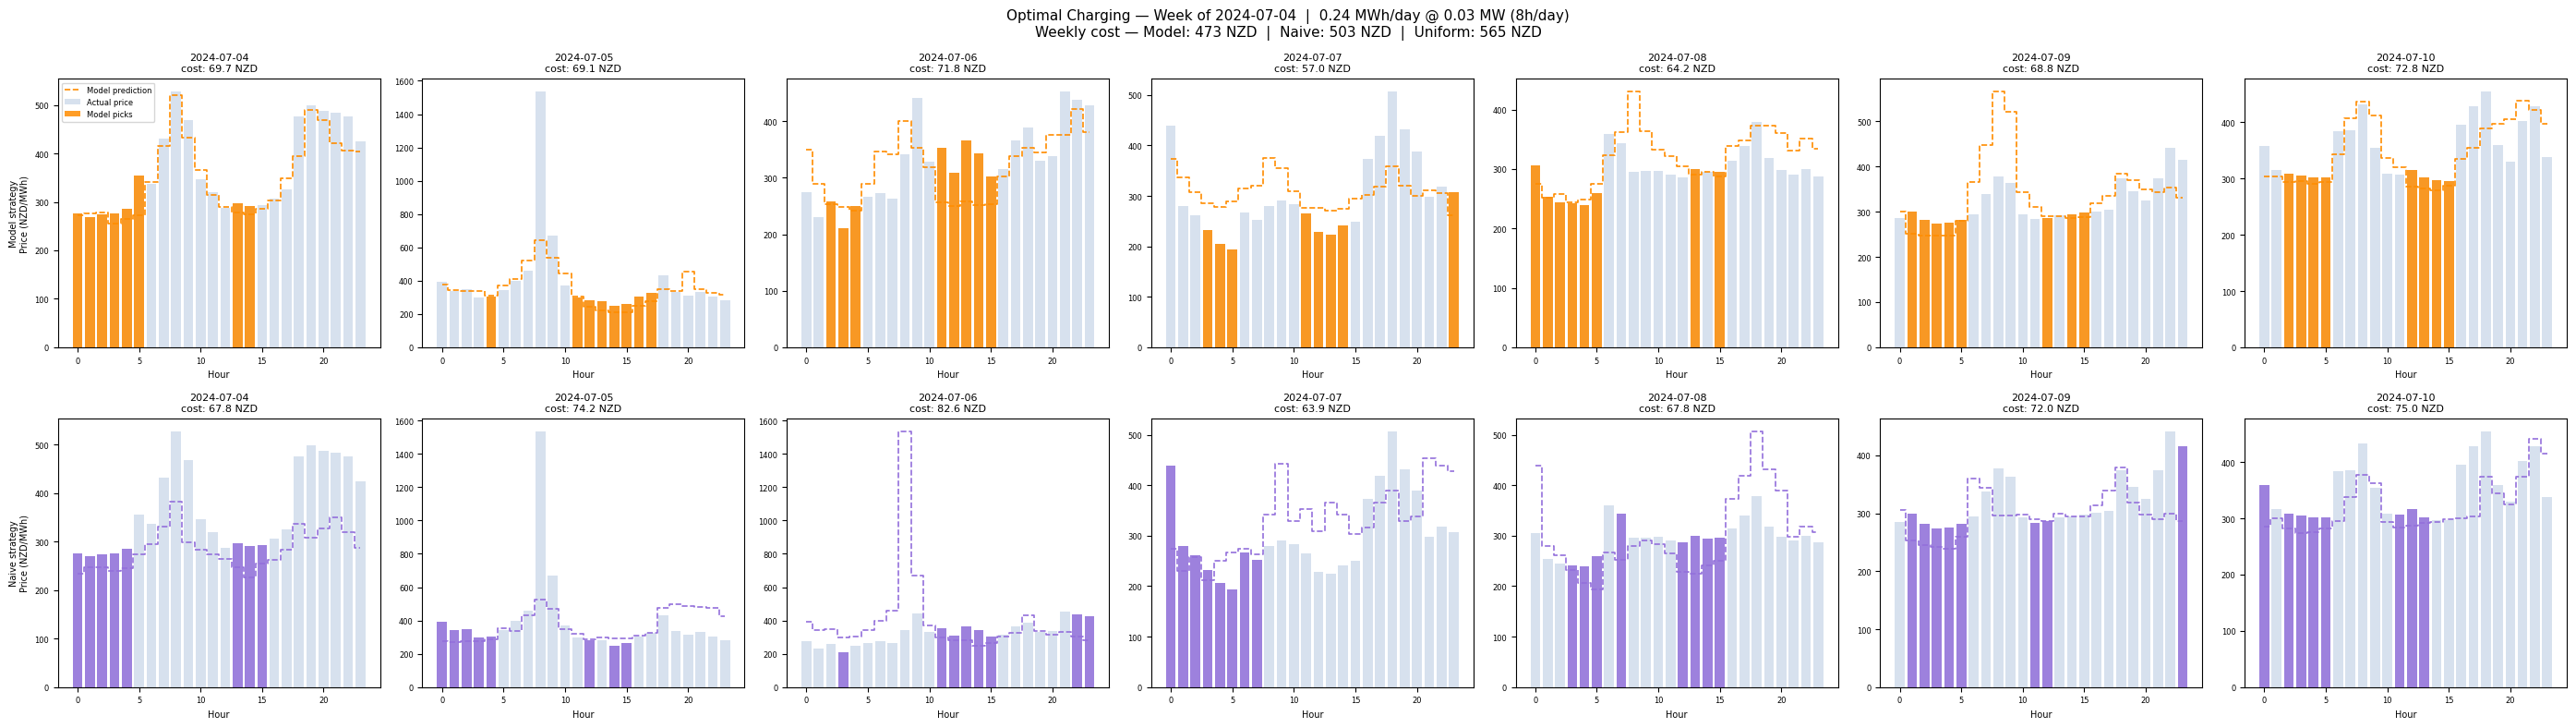

In [104]:
# ══════════════════════════════════════════════════════════════════════════════
# OPTIMAL CHARGING SCHEDULER
# ══════════════════════════════════════════════════════════════════════════════

# ── USER INPUTS ───────────────────────────────────────────────────────────────

WEEK_START       = "2024-07-04"
DAILY_ENERGY_MWH = 0.24
MACHINE_POWER_MW = 0.03

# ── DERIVED ───────────────────────────────────────────────────────────────────

HOURS_PER_DAY = int(np.ceil(DAILY_ENERGY_MWH / MACHINE_POWER_MW))
print(f"Daily energy required : {DAILY_ENERGY_MWH} MWh")
print(f"Machine power         : {MACHINE_POWER_MW} MW")
print(f"Consumption hours/day : {HOURS_PER_DAY}h  "
      f"({MACHINE_POWER_MW} MW × {HOURS_PER_DAY}h = "
      f"{MACHINE_POWER_MW * HOURS_PER_DAY:.1f} MWh/day)")

# ── FETCH WEEK DATA ───────────────────────────────────────────────────────────

week_start_ts = pd.Timestamp(WEEK_START)
week_end_ts   = week_start_ts + pd.Timedelta(days=7)

mask    = (df["datetime_utc12"] >= week_start_ts) & (df["datetime_utc12"] < week_end_ts)
week_df = df[mask].reset_index(drop=True)

if len(week_df) == 0:
    raise ValueError(f"No data found for week starting {WEEK_START}.")

y_pred_week   = model.predict(week_df[feature_cols].values)
y_actual_week = week_df[target_col].values
y_naive_week  = week_df["target_lag_24h"].values
timestamps    = week_df["datetime_utc12"].values

# ── SCHEDULE CHEAPEST HOURS PER DAY ──────────────────────────────────────────

schedule = []

for day_offset in range(7):
    day_start = week_start_ts + pd.Timedelta(days=day_offset)
    day_end   = day_start + pd.Timedelta(hours=24)

    day_mask = (week_df["datetime_utc12"] >= day_start) & (week_df["datetime_utc12"] < day_end)
    day_idx  = np.where(day_mask)[0]

    if len(day_idx) < 24:
        continue

    pred_day   = y_pred_week[day_idx]
    actual_day = y_actual_week[day_idx]
    naive_day  = y_naive_week[day_idx]

    model_chosen   = np.argsort(pred_day)[:HOURS_PER_DAY]
    naive_chosen   = np.argsort(naive_day)[:HOURS_PER_DAY]
    uniform_chosen = np.linspace(0, 23, HOURS_PER_DAY, dtype=int)

    model_cost   = actual_day[model_chosen].mean()   * MACHINE_POWER_MW * HOURS_PER_DAY
    naive_cost   = actual_day[naive_chosen].mean()   * MACHINE_POWER_MW * HOURS_PER_DAY
    uniform_cost = actual_day[uniform_chosen].mean() * MACHINE_POWER_MW * HOURS_PER_DAY

    schedule.append({
        "date":           day_start.date(),
        "pred_day":       pred_day,
        "actual_day":     actual_day,
        "naive_day":      naive_day,
        "model_chosen":   model_chosen,
        "naive_chosen":   naive_chosen,
        "uniform_chosen": uniform_chosen,
        "model_cost":     model_cost,
        "naive_cost":     naive_cost,
        "uniform_cost":   uniform_cost,
    })

# ── WEEKLY COST SUMMARY ───────────────────────────────────────────────────────

total_model   = sum(d["model_cost"]   for d in schedule)
total_naive   = sum(d["naive_cost"]   for d in schedule)
total_uniform = sum(d["uniform_cost"] for d in schedule)

print(f"\n{'─'*52}")
print(f"{'Date':<14} {'Model (NZD)':>12} {'Naive (NZD)':>12} {'Uniform (NZD)':>14}")
print(f"{'─'*52}")
for d in schedule:
    print(f"{str(d['date']):<14} {d['model_cost']:>12.2f} {d['naive_cost']:>12.2f} {d['uniform_cost']:>14.2f}")
print(f"{'─'*52}")
print(f"{'TOTAL':<14} {total_model:>12.2f} {total_naive:>12.2f} {total_uniform:>14.2f}")
print(f"\nSavings vs uniform — Model: {total_uniform - total_model:.2f} NZD  "
      f"({100*(total_uniform-total_model)/total_uniform:.1f}%)")
print(f"Savings vs uniform — Naive: {total_uniform - total_naive:.2f} NZD  "
      f"({100*(total_uniform-total_naive)/total_uniform:.1f}%)")
print(f"Model vs Naive     — Model saves: {total_naive - total_model:.2f} NZD  "
      f"({100*(total_naive-total_model)/total_naive:.1f}%)")

# ── VISUALISATION ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 7, figsize=(28, 8), sharey=False)
fig.suptitle(
    f"Optimal Charging — Week of {WEEK_START}  |  "
    f"{DAILY_ENERGY_MWH} MWh/day @ {MACHINE_POWER_MW} MW ({HOURS_PER_DAY}h/day)\n"
    f"Weekly cost — Model: {total_model:.0f} NZD  |  "
    f"Naive: {total_naive:.0f} NZD  |  Uniform: {total_uniform:.0f} NZD",
    fontsize=11
)

hours = np.arange(24)

strategies = [
    ("model",  "Model",  "darkorange",   "Model prediction", "darkorange"),
    ("naive",  "Naive",  "mediumpurple", "Naive (lag 24h)",  "mediumpurple"),
]

for row, (key, label, bar_color, line_label, line_color) in enumerate(strategies):
    for col, d in enumerate(schedule):
        ax = axes[row][col]

        chosen     = d[f"{key}_chosen"]
        cost       = d[f"{key}_cost"]
        price_line = d["pred_day"] if key == "model" else d["naive_day"]

        ax.bar(hours, d["actual_day"], color="lightsteelblue", alpha=0.5, label="Actual price")
        ax.bar(hours[chosen], d["actual_day"][chosen], color=bar_color, alpha=0.85,
               label=f"{label} picks")
        ax.step(hours, price_line, where="mid", color=line_color,
                linewidth=1.2, linestyle="--", label=line_label)

        day_str  = str(d["date"])
        cost_str = f"{cost:.1f} NZD"
        ax.set_title(f"{day_str}\ncost: {cost_str}", fontsize=8)
        ax.set_xlabel("Hour", fontsize=7)
        if col == 0:
            ax.set_ylabel(f"{label} strategy\nPrice (NZD/MWh)", fontsize=7)
        ax.tick_params(labelsize=6)
        if col == 0 and row == 0:
            ax.legend(fontsize=6, loc="upper left")

plt.tight_layout()
plt.show()

Settings: 0.24 MWh/day  @  0.02 MW  (12h/day)

        Week     Uniform       Model       Naive   Save Model   Save Naive   Mdl vs Naive
──────────────────────────────────────────────────────────────────────────────────
  2024-01-01      260.47      230.72      245.77       +29.75       +14.70         +15.06
  2024-01-08      393.24      359.90      376.56       +33.33       +16.68         +16.66
  2024-01-15      486.30      422.45      431.62       +63.85       +54.67          +9.18
  2024-01-22      249.29      211.79      215.52       +37.50       +33.76          +3.74
  2024-01-29      164.31       92.17      146.04       +72.14       +18.27         +53.87
  2024-02-05      212.59      176.67      185.51       +35.92       +27.08          +8.84
  2024-02-12      290.11      263.45      271.78       +26.66       +18.33          +8.32
  2024-02-19      331.08      272.68      300.02       +58.41       +31.06         +27.35
  2024-02-26      348.96      310.29      320.65       +38.6

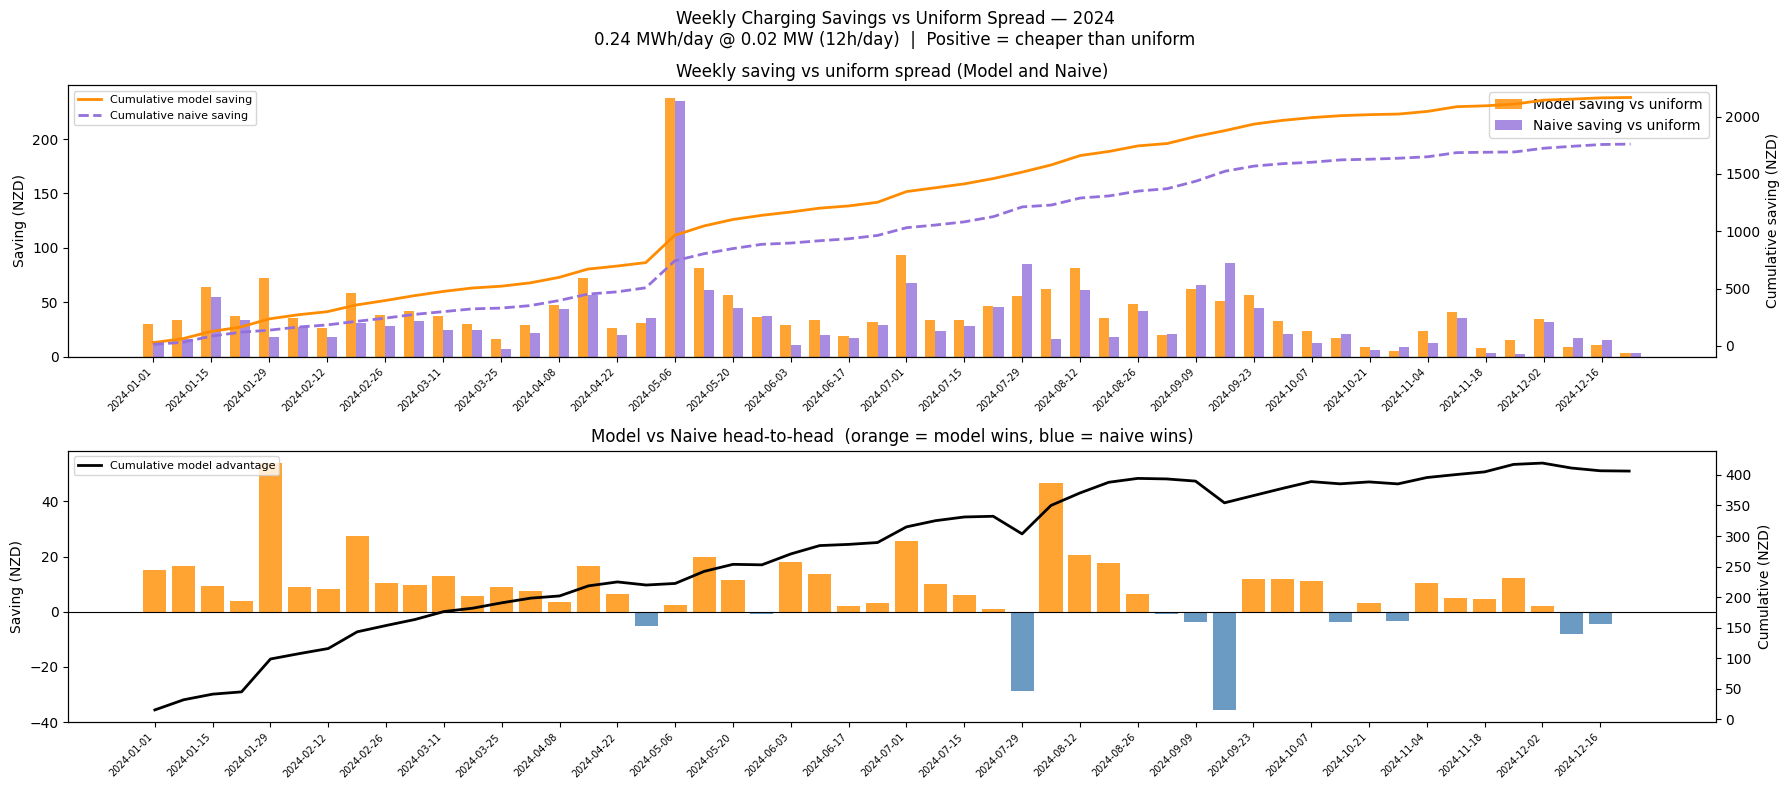

In [102]:
# ══════════════════════════════════════════════════════════════════════════════
# CHARGING SCHEDULER — ALL 52 WEEKS OF 2024
# Uses same DAILY_ENERGY_MWH and MACHINE_POWER_MW from the cell above.
# Positive saving = model/naive paid less than uniform (good).
# Negative saving = model/naive paid more than uniform (bad).
# ══════════════════════════════════════════════════════════════════════════════

weekly_savings = []

for week_start in pd.date_range("2024-01-01", "2024-12-25", freq="7D"):
    ws_ts  = week_start
    we_ts  = ws_ts + pd.Timedelta(days=7)

    mask    = (df["datetime_utc12"] >= ws_ts) & (df["datetime_utc12"] < we_ts)
    wdf     = df[mask].reset_index(drop=True)

    if len(wdf) < 168:
        continue

    y_pred_w   = model.predict(wdf[feature_cols].values)
    y_actual_w = wdf[target_col].values
    y_naive_w  = wdf["target_lag_24h"].values

    w_model   = 0.0
    w_naive   = 0.0
    w_uniform = 0.0

    for day_offset in range(7):
        ds = ws_ts + pd.Timedelta(days=day_offset)
        de = ds + pd.Timedelta(hours=24)

        dmask = (wdf["datetime_utc12"] >= ds) & (wdf["datetime_utc12"] < de)
        didx  = np.where(dmask)[0]

        if len(didx) < 24:
            continue

        pred_d   = y_pred_w[didx]
        actual_d = y_actual_w[didx]
        naive_d  = y_naive_w[didx]

        mc = np.argsort(pred_d)[:HOURS_PER_DAY]
        nc = np.argsort(naive_d)[:HOURS_PER_DAY]
        uc = np.linspace(0, 23, HOURS_PER_DAY, dtype=int)

        w_model   += actual_d[mc].mean() * MACHINE_POWER_MW * HOURS_PER_DAY
        w_naive   += actual_d[nc].mean() * MACHINE_POWER_MW * HOURS_PER_DAY
        w_uniform += actual_d[uc].mean() * MACHINE_POWER_MW * HOURS_PER_DAY

    weekly_savings.append({
        "week_start":      week_start.date(),
        "cost_model":      w_model,
        "cost_naive":      w_naive,
        "cost_uniform":    w_uniform,
        "saving_model":    w_uniform - w_model,   # + = cheaper than uniform
        "saving_naive":    w_uniform - w_naive,
        "model_vs_naive":  w_naive   - w_model,   # + = model cheaper than naive
    })

sdf = pd.DataFrame(weekly_savings)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"Settings: {DAILY_ENERGY_MWH} MWh/day  @  {MACHINE_POWER_MW} MW  ({HOURS_PER_DAY}h/day)\n")
print(f"{'Week':>12}  {'Uniform':>10}  {'Model':>10}  {'Naive':>10}  "
      f"{'Save Model':>11}  {'Save Naive':>11}  {'Mdl vs Naive':>13}")
print("─" * 82)
for _, r in sdf.iterrows():
    print(f"{str(r['week_start']):>12}  {r['cost_uniform']:>10.2f}  {r['cost_model']:>10.2f}  "
          f"{r['cost_naive']:>10.2f}  {r['saving_model']:>+11.2f}  "
          f"{r['saving_naive']:>+11.2f}  {r['model_vs_naive']:>+13.2f}")
print("─" * 82)
print(f"{'TOTAL':>12}  {sdf['cost_uniform'].sum():>10.2f}  {sdf['cost_model'].sum():>10.2f}  "
      f"{sdf['cost_naive'].sum():>10.2f}  {sdf['saving_model'].sum():>+11.2f}  "
      f"{sdf['saving_naive'].sum():>+11.2f}  {sdf['model_vs_naive'].sum():>+13.2f}")

pct_m = 100 * sdf["saving_model"].sum()   / sdf["cost_uniform"].sum()
pct_n = 100 * sdf["saving_naive"].sum()   / sdf["cost_uniform"].sum()
pct_v = 100 * sdf["model_vs_naive"].sum() / sdf["cost_naive"].sum()
print(f"\nFull-year savings vs uniform — Model: {pct_m:+.1f}%   Naive: {pct_n:+.1f}%")
print(f"Full-year model vs naive               Model: {pct_v:+.1f}%")

# ── Figure ────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(18, 8))
fig.suptitle(
    f"Weekly Charging Savings vs Uniform Spread — 2024\n"
    f"{DAILY_ENERGY_MWH} MWh/day @ {MACHINE_POWER_MW} MW ({HOURS_PER_DAY}h/day)  |  "
    f"Positive = cheaper than uniform",
    fontsize=12
)

weeks  = np.arange(len(sdf))
labels = [str(w) for w in sdf["week_start"]]

# ── Panel 1: Model vs Naive vs Uniform ────────────────────────────────────────
ax1 = axes[0]
w = 0.35
ax1.bar(weeks - w/2, sdf["saving_model"], width=w, color="darkorange",
        alpha=0.8, label="Model saving vs uniform")
ax1.bar(weeks + w/2, sdf["saving_naive"], width=w, color="mediumpurple",
        alpha=0.8, label="Naive saving vs uniform")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(weeks[::2])
ax1.set_xticklabels(labels[::2], rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Saving (NZD)")
ax1.set_title("Weekly saving vs uniform spread (Model and Naive)")
ax1.legend()

# Running cumulative line
ax1b = ax1.twinx()
ax1b.plot(weeks, sdf["saving_model"].cumsum(), color="darkorange",
          linewidth=2, linestyle="-", label="Cumulative model saving")
ax1b.plot(weeks, sdf["saving_naive"].cumsum(), color="mediumpurple",
          linewidth=2, linestyle="--", label="Cumulative naive saving")
ax1b.set_ylabel("Cumulative saving (NZD)")
ax1b.legend(loc="upper left", fontsize=8)

# ── Panel 2: Model vs Naive (head-to-head) ────────────────────────────────────
ax2 = axes[1]
colors = ["darkorange" if v >= 0 else "steelblue" for v in sdf["model_vs_naive"]]
ax2.bar(weeks, sdf["model_vs_naive"], color=colors, alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(weeks[::2])
ax2.set_xticklabels(labels[::2], rotation=45, ha="right", fontsize=7)
ax2.set_ylabel("Saving (NZD)")
ax2.set_title("Model vs Naive head-to-head  (orange = model wins, blue = naive wins)")

ax2b = ax2.twinx()
ax2b.plot(weeks, sdf["model_vs_naive"].cumsum(), color="black",
          linewidth=2, label="Cumulative model advantage")
ax2b.set_ylabel("Cumulative (NZD)")
ax2b.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()